In [3]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
import warnings
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath("../../"))

from utils.evaluate_alerting import evaluate_alert_hitrate, summarize_alert_hitrate

In [4]:
DATA_PATH = "../../data/vitals_data"

top_dir = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
df = None
for t in top_dir:
    df_i = pd.read_parquet(f"{DATA_PATH}/mimic_vitals_p0{t}.parquet")
    if df is None:
        df = df_i
    else:
        df = pd.concat([df, df_i])

In [5]:
len(df["Record"].unique())

11105

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 13288294 entries, 0 to 1088333
Data columns (total 11 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Patient              str    
 1   Record               str    
 2   Minute               int64  
 3   HR                   float64
 4   RESP                 float64
 5   SpO2                 float64
 6   ABP Sys              float64
 7   ABP Dias             float64
 8   NBP Sys              float64
 9   NBP Dias             float64
 10  PVC Rate per Minute  float64
dtypes: float64(8), int64(1), str(2)
memory usage: 1.6 GB


In [10]:
### ran once to generate test set, reuse ###
'''
sampled_records = df["Record"].drop_duplicates().sample(2000, random_state=42)
np.save(f"{DATA_PATH}/../test_records.npy", sampled_records.to_numpy())
'''
pass

In [15]:
sampled_records = np.load(f"{DATA_PATH}/../test_records.npy", allow_pickle=True)
sampled_df = df[df["Record"].isin(sampled_records)]
len(sampled_df['Record'].unique())

2000

  p001028-2168-03-09-15-41n | HR | order=(3, 0, 1) | MAE=3.402 | MAPE=4.307 | RMSE=3.461
  p001028-2168-03-09-15-41n | RESP | order=(0, 1, 1) | MAE=1.928 | MAPE=7.548 | RMSE=2.191
  p001028-2168-03-09-15-41n | SpO2 | order=(0, 1, 0) | MAE=0.830 | MAPE=0.838 | RMSE=0.880


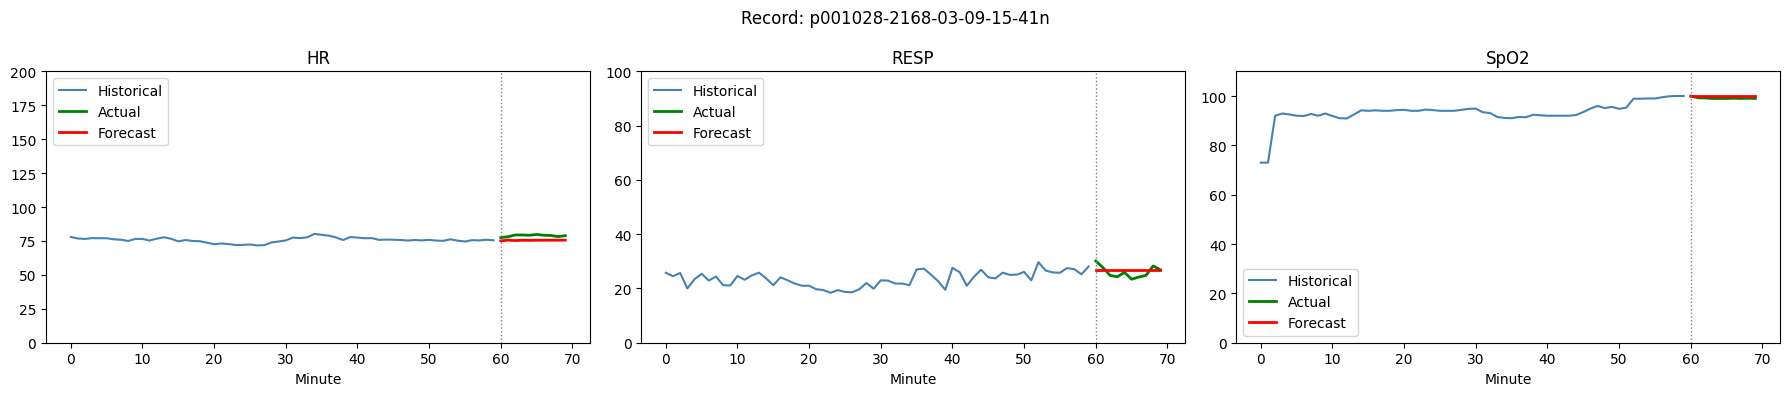

  p002067-2191-03-09-14-58n | HR | order=(1, 0, 0) | MAE=0.920 | MAPE=1.292 | RMSE=1.097
  p002067-2191-03-09-14-58n | RESP | order=(1, 0, 1) | MAE=2.191 | MAPE=9.630 | RMSE=2.450
  p002067-2191-03-09-14-58n | SpO2 | order=(1, 0, 0) | MAE=0.373 | MAPE=0.380 | RMSE=0.434


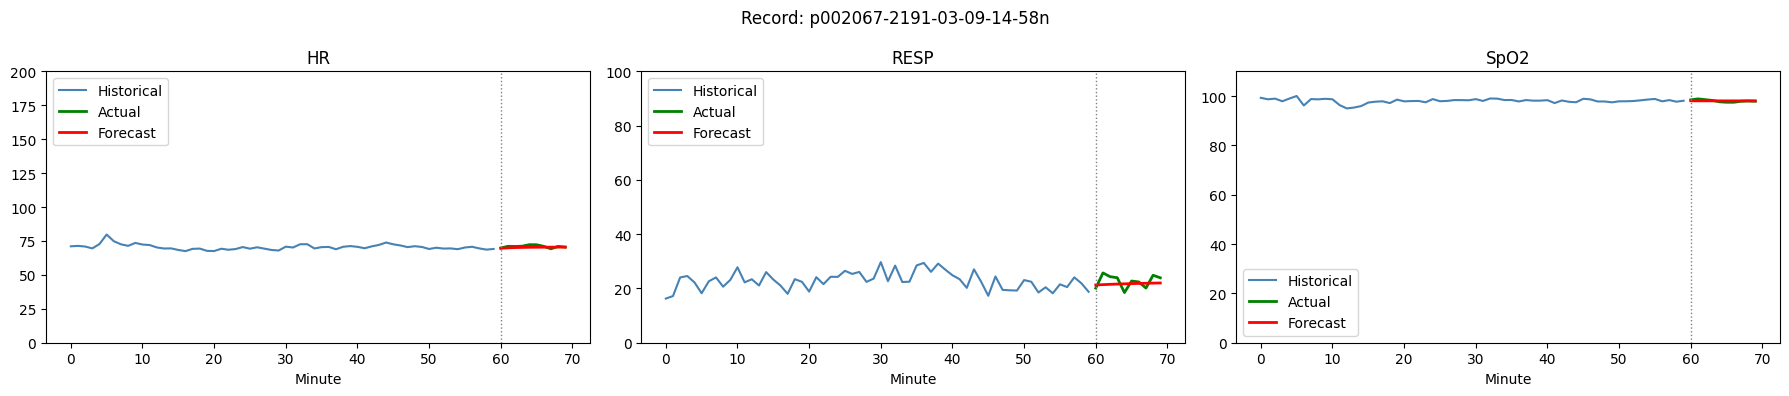

  p003214-2164-08-17-19-20n | HR | order=(0, 0, 1) | MAE=3.706 | MAPE=3.239 | RMSE=4.289
  p003214-2164-08-17-19-20n | RESP | order=(1, 0, 0) | MAE=2.096 | MAPE=10.644 | RMSE=2.521
  p003214-2164-08-17-19-20n | SpO2 | order=(1, 0, 0) | MAE=1.253 | MAPE=1.332 | RMSE=1.800


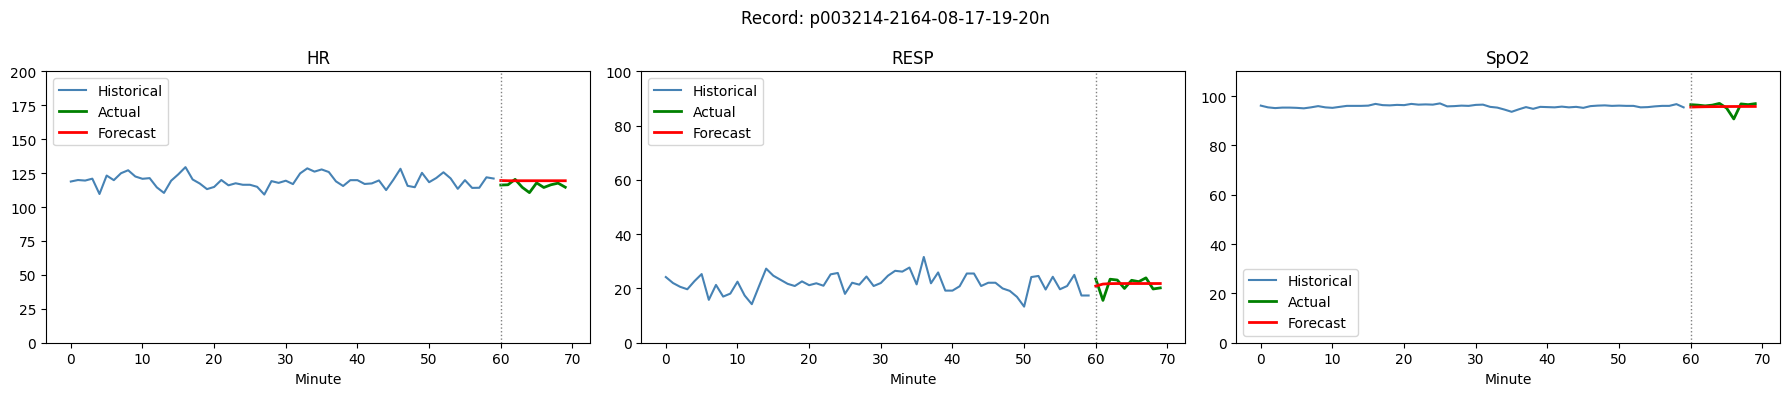

  p004348-2137-10-04-17-12n | HR | order=(1, 0, 0) | MAE=1.006 | MAPE=1.565 | RMSE=1.150
  p004348-2137-10-04-17-12n | RESP | order=(2, 0, 0) | MAE=0.293 | MAPE=1.874 | RMSE=0.403
  p004348-2137-10-04-17-12n | SpO2 | order=(1, 0, 0) | MAE=2.375 | MAPE=2.375 | RMSE=2.402


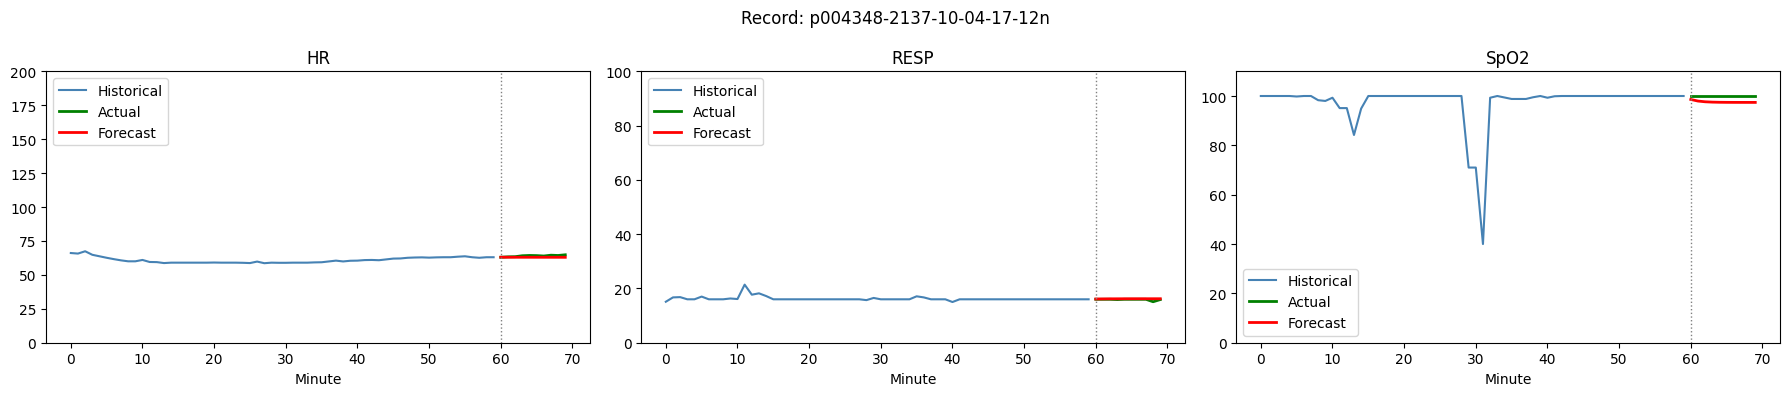

  p005885-2195-05-14-14-43n | HR | order=(0, 1, 1) | MAE=0.627 | MAPE=0.666 | RMSE=0.747
  p005885-2195-05-14-14-43n | RESP | order=(0, 1, 1) | MAE=0.896 | MAPE=2.867 | RMSE=1.257
  p005885-2195-05-14-14-43n | SpO2 | order=(0, 1, 1) | MAE=0.228 | MAPE=0.228 | RMSE=0.250


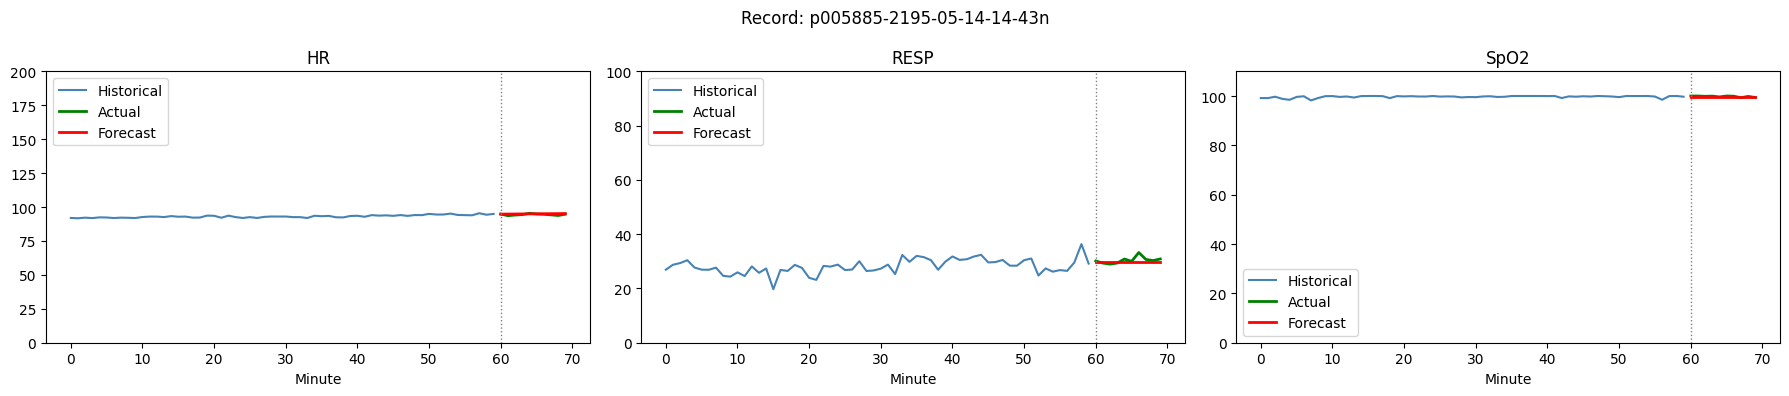

  p006889-2182-12-27-11-29n | HR | order=(4, 1, 0) | MAE=1.766 | MAPE=1.966 | RMSE=1.840
  p006889-2182-12-27-11-29n | RESP | order=(1, 0, 1) | MAE=0.902 | MAPE=25.779 | RMSE=0.902
  p006889-2182-12-27-11-29n | SpO2 | order=(0, 0, 0) | MAE=0.000 | MAPE=0.000 | RMSE=0.000


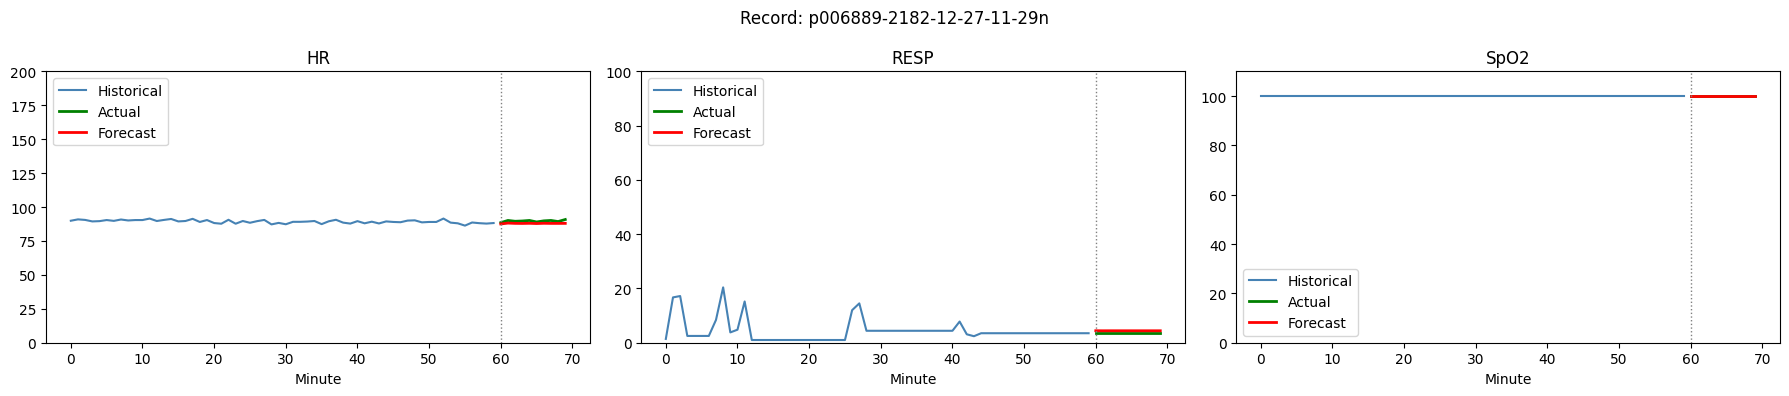

  p007968-2135-09-04-12-05n | HR | order=(0, 1, 0) | MAE=0.955 | MAPE=1.733 | RMSE=1.182
  p007968-2135-09-04-12-05n | RESP | order=(1, 0, 1) | MAE=1.632 | MAPE=9.217 | RMSE=1.931
  p007968-2135-09-04-12-05n | SpO2 | order=(0, 0, 0) | MAE=0.311 | MAPE=0.329 | RMSE=0.432


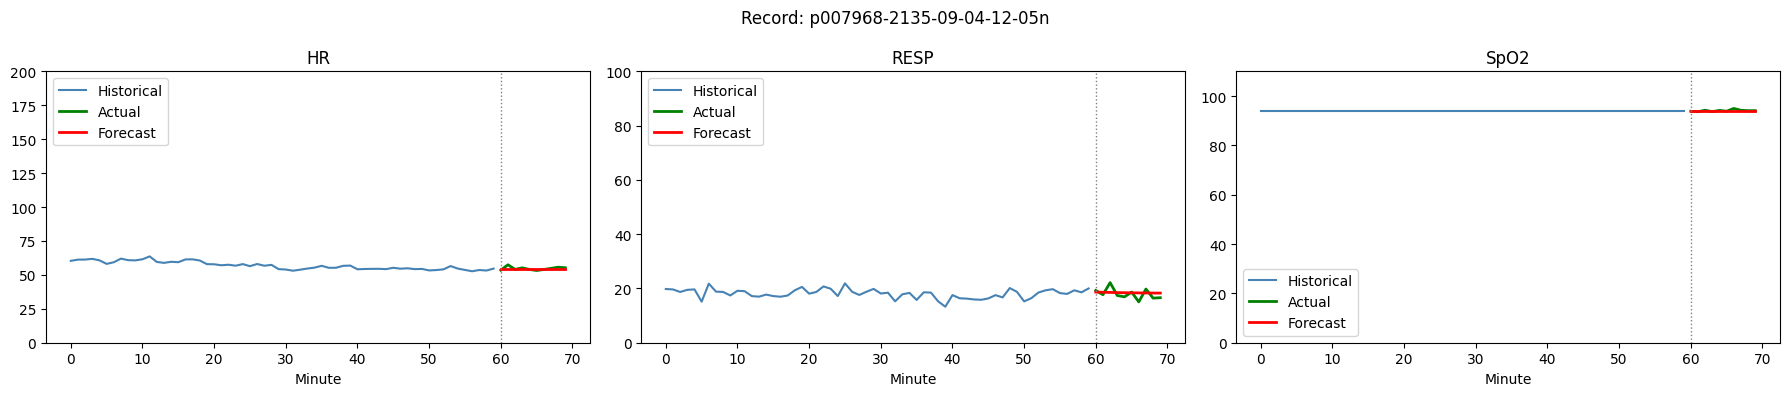

  p009258-2154-10-11-17-59n | HR | order=(1, 2, 1) | MAE=11.845 | MAPE=10.811 | RMSE=15.248
  p009258-2154-10-11-17-59n | RESP | order=(2, 0, 2) | MAE=5.381 | MAPE=35.477 | RMSE=6.334
  p009258-2154-10-11-17-59n | SpO2 | order=(1, 0, 0) | MAE=5.465 | MAPE=6.064 | RMSE=5.584


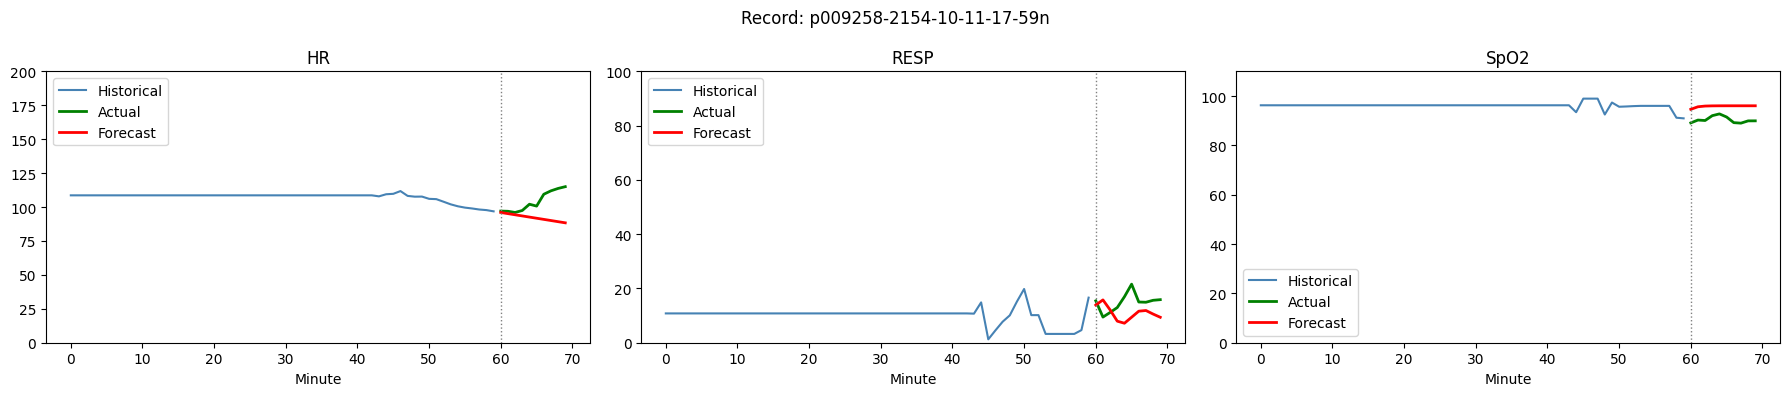

  p010611-2131-07-16-10-49n | HR | order=(0, 0, 1) | MAE=0.420 | MAPE=0.486 | RMSE=0.537
  p010611-2131-07-16-10-49n | RESP | order=(1, 0, 0) | MAE=0.465 | MAPE=4.650 | RMSE=0.470
  p010611-2131-07-16-10-49n | SpO2 | order=(0, 0, 0) | MAE=0.000 | MAPE=0.000 | RMSE=0.000


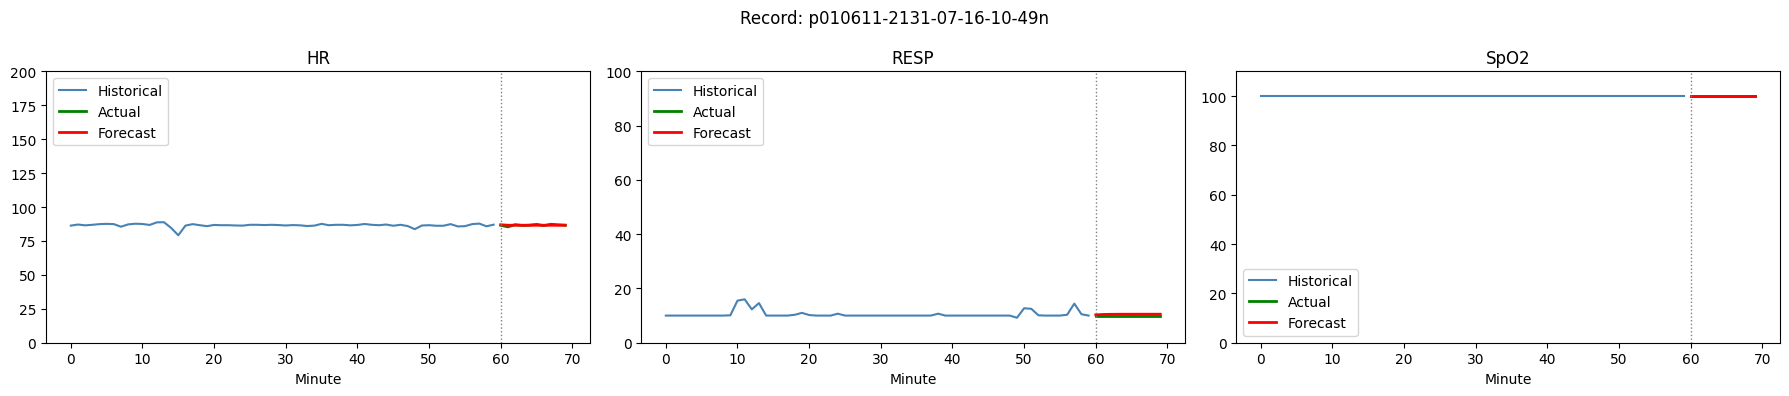

  p011850-2193-08-28-18-51n | HR | order=(1, 0, 2) | MAE=1.039 | MAPE=2.109 | RMSE=1.295
  p011850-2193-08-28-18-51n | RESP | order=(0, 0, 2) | MAE=1.069 | MAPE=4.775 | RMSE=1.387
  p011850-2193-08-28-18-51n | SpO2 | order=(0, 0, 2) | MAE=1.773 | MAPE=1.840 | RMSE=2.424


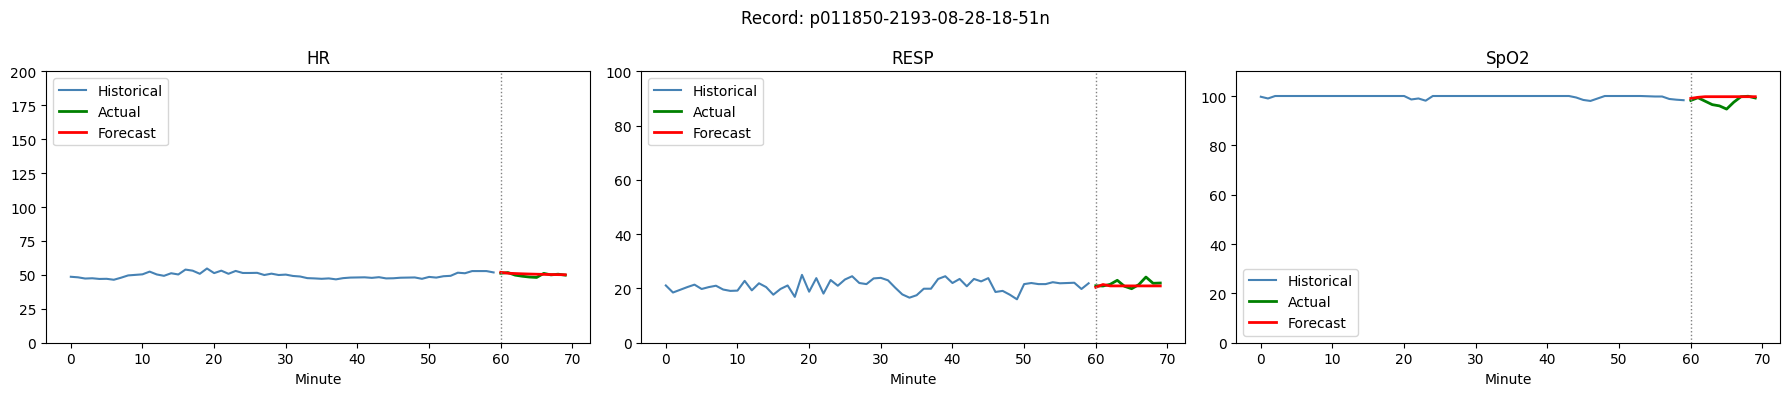

  p013101-2123-09-23-09-50n | HR | order=(0, 0, 0) | MAE=0.000 | MAPE=0.000 | RMSE=0.000
  p013101-2123-09-23-09-50n | RESP | order=(0, 1, 0) | MAE=2.100 | MAPE=11.270 | RMSE=2.704
  p013101-2123-09-23-09-50n | SpO2 | order=(0, 1, 0) | MAE=0.920 | MAPE=0.960 | RMSE=0.977


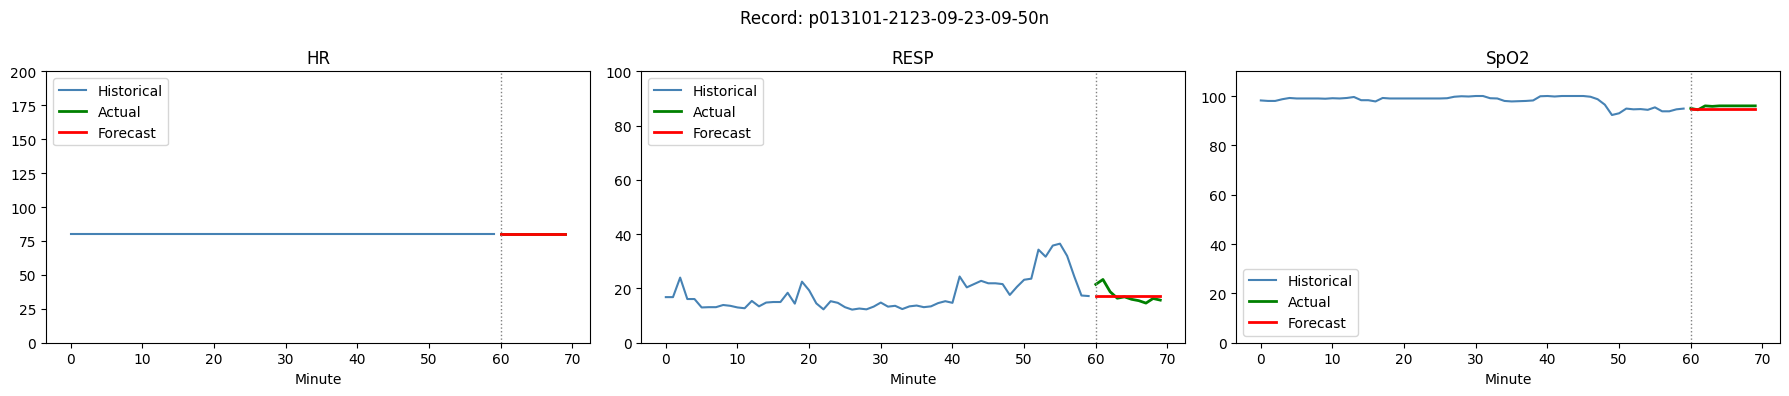

  p014328-2106-03-23-20-45n | HR | order=(0, 1, 1) | MAE=4.231 | MAPE=6.687 | RMSE=4.951
  p014328-2106-03-23-20-45n | RESP | order=(0, 0, 0) | MAE=0.279 | MAPE=1.721 | RMSE=0.298
  p014328-2106-03-23-20-45n | SpO2 | order=(1, 1, 1) | MAE=0.897 | MAPE=0.947 | RMSE=1.093


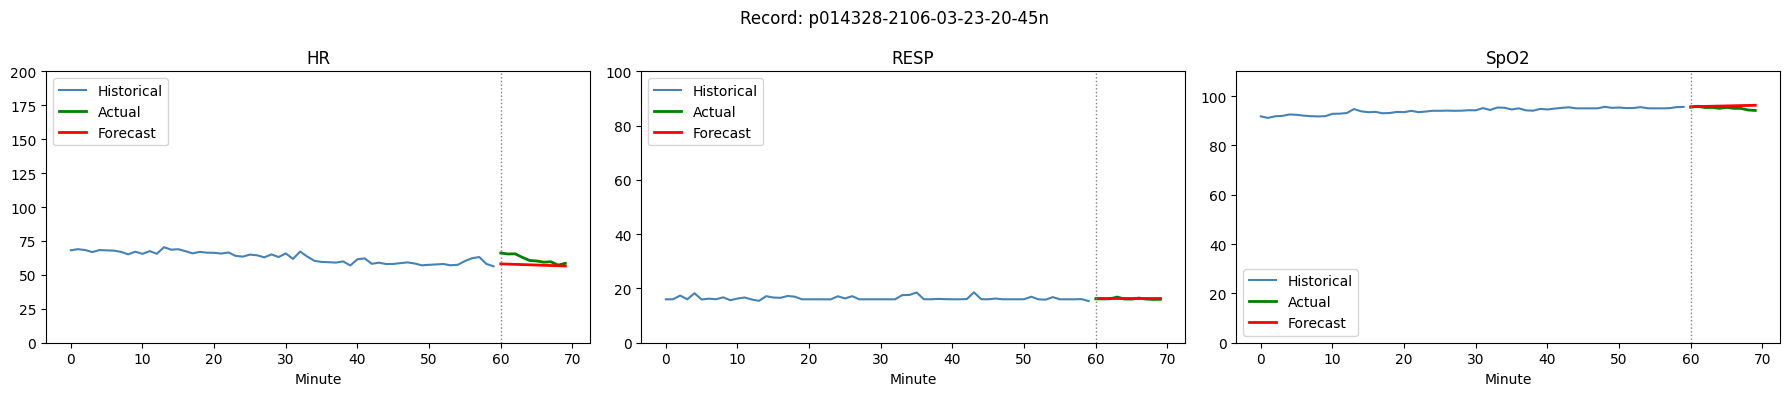

  p015885-2133-11-16-12-23n | HR | order=(0, 1, 0) | MAE=0.230 | MAPE=0.306 | RMSE=0.277
  p015885-2133-11-16-12-23n | RESP | order=(0, 1, 2) | MAE=0.556 | MAPE=5.558 | RMSE=0.556
  p015885-2133-11-16-12-23n | SpO2 | order=(0, 0, 0) | MAE=0.002 | MAPE=0.002 | RMSE=0.002


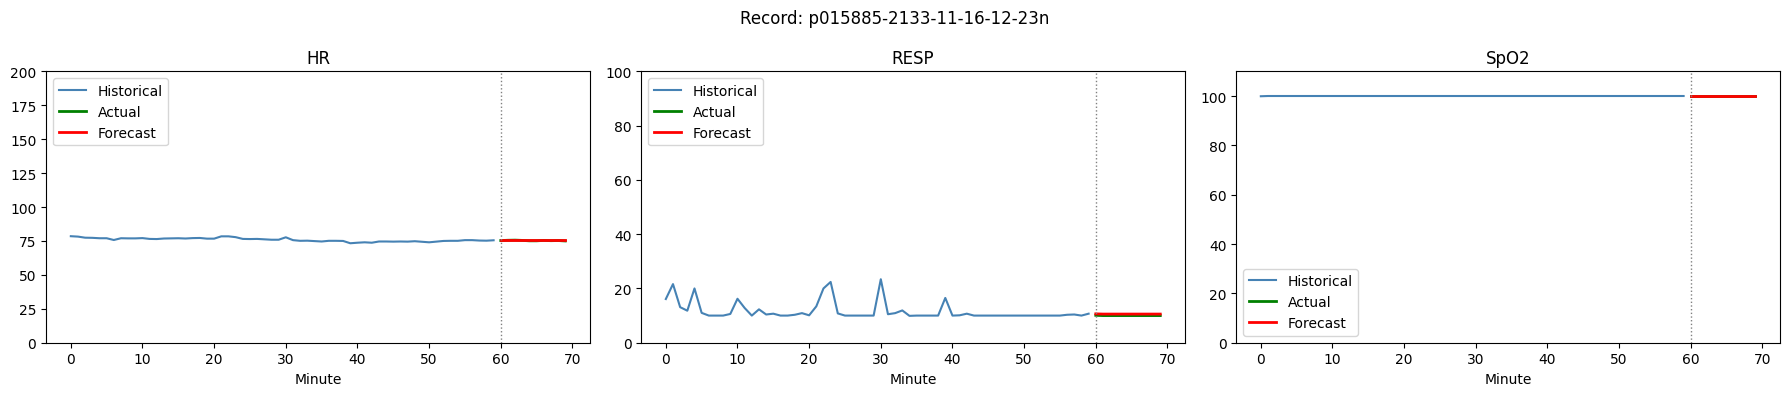

  p016874-2183-10-19-14-08n | HR | order=(2, 1, 2) | MAE=2.027 | MAPE=2.562 | RMSE=2.559
  p016874-2183-10-19-14-08n | RESP | order=(0, 1, 1) | MAE=1.161 | MAPE=6.550 | RMSE=1.491
  p016874-2183-10-19-14-08n | SpO2 | order=(0, 1, 0) | MAE=0.580 | MAPE=0.644 | RMSE=0.603


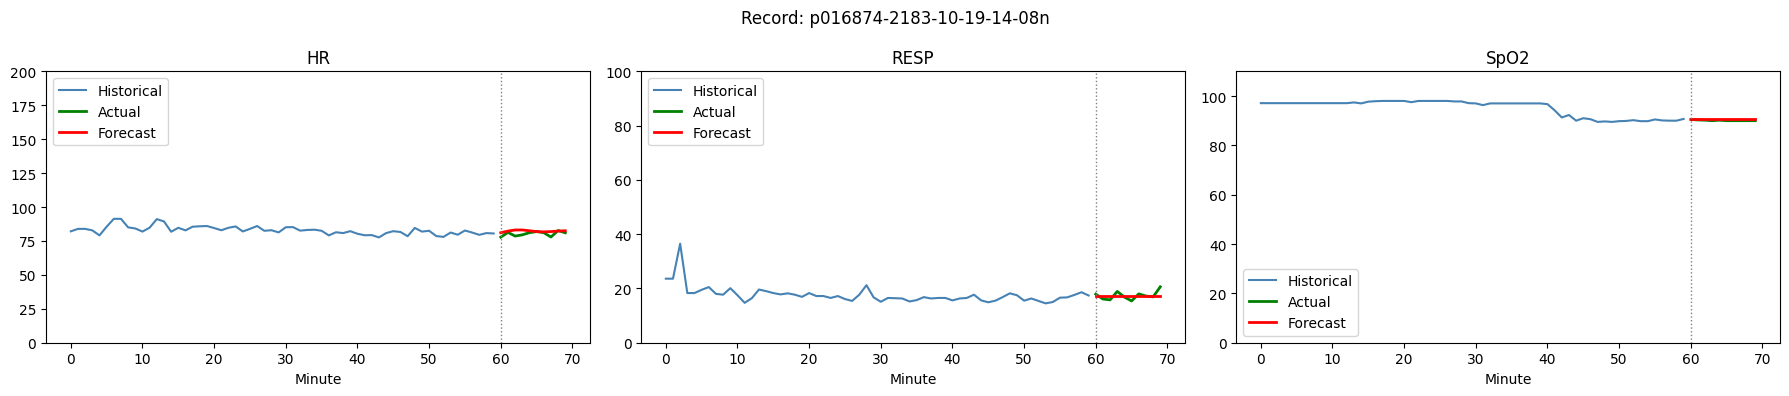

  p018248-2174-09-12-12-07n | HR | order=(1, 1, 1) | MAE=0.456 | MAPE=0.602 | RMSE=0.478
  p018248-2174-09-12-12-07n | RESP | order=(1, 1, 1) | MAE=0.666 | MAPE=3.554 | RMSE=0.930
  p018248-2174-09-12-12-07n | SpO2 | order=(0, 1, 0) | MAE=0.210 | MAPE=0.213 | RMSE=0.243


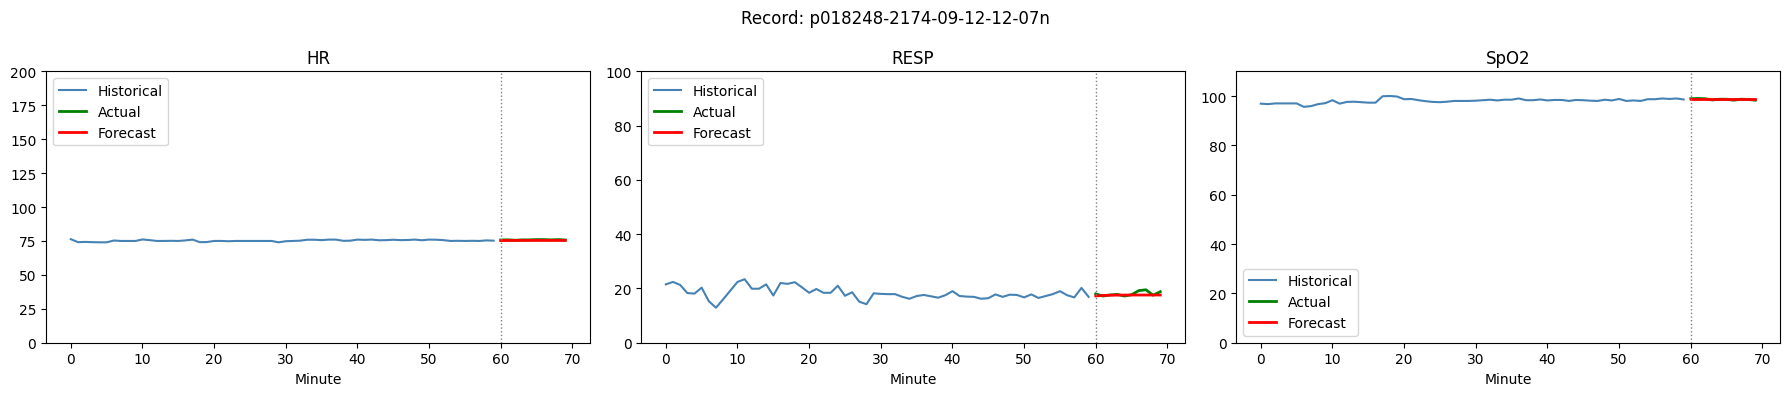

  p019371-2196-04-05-09-31n | HR | order=(0, 1, 1) | MAE=3.087 | MAPE=3.137 | RMSE=3.375
  p019371-2196-04-05-09-31n | RESP | order=(1, 0, 0) | MAE=1.242 | MAPE=4.706 | RMSE=1.465
  p019371-2196-04-05-09-31n | SpO2 | order=(0, 1, 1) | MAE=0.433 | MAPE=0.456 | RMSE=0.506


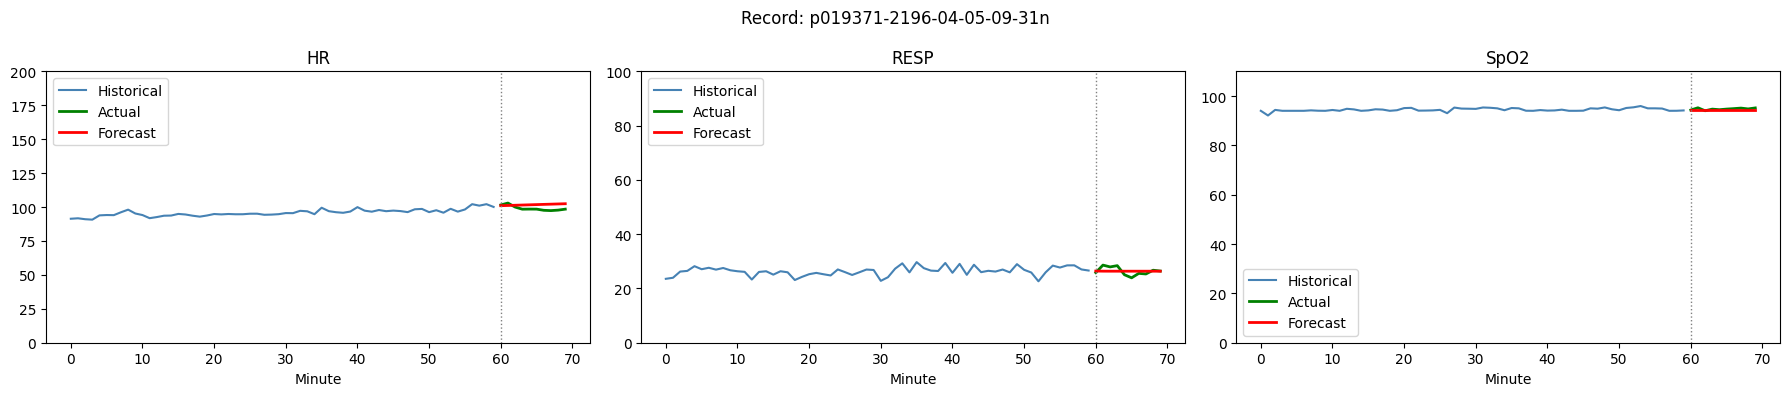

  p020940-2136-04-03-19-21n | HR | order=(1, 0, 0) | MAE=1.374 | MAPE=1.705 | RMSE=1.458
  p020940-2136-04-03-19-21n | RESP | order=(0, 1, 2) | MAE=1.847 | MAPE=7.727 | RMSE=2.300
  p020940-2136-04-03-19-21n | SpO2 | order=(0, 0, 0) | MAE=0.000 | MAPE=0.000 | RMSE=0.000


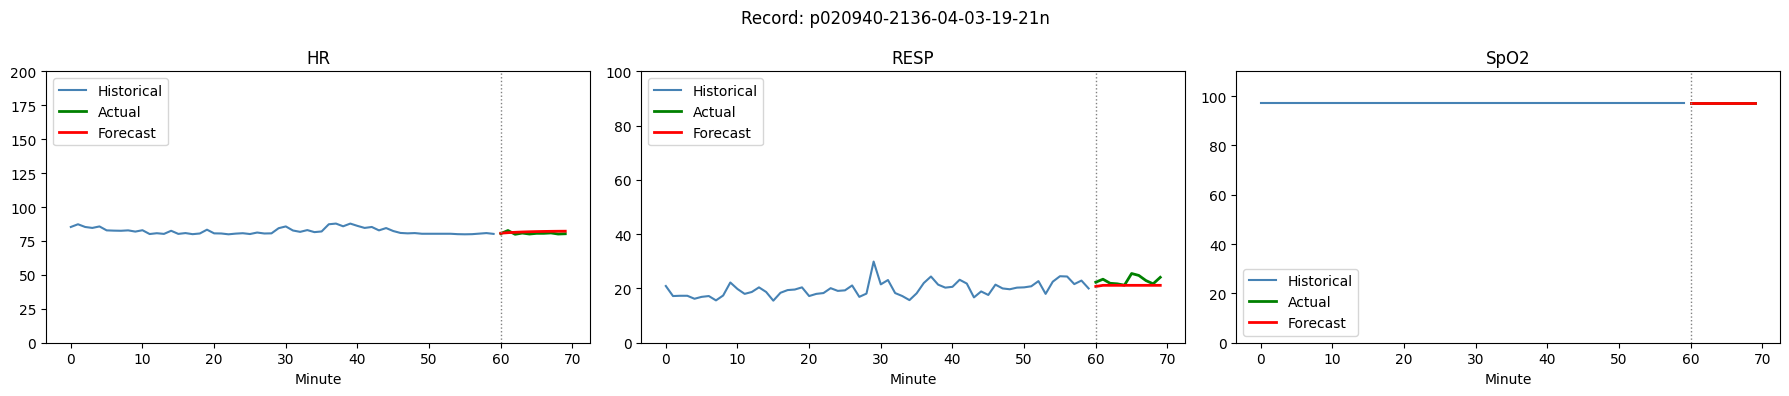

  p022120-2120-10-07-19-48n | HR | order=(0, 1, 0) | MAE=0.783 | MAPE=0.872 | RMSE=0.997
  p022120-2120-10-07-19-48n | RESP | order=(0, 0, 2) | MAE=5.337 | MAPE=584.407 | RMSE=8.042
  p022120-2120-10-07-19-48n | SpO2 | order=(1, 0, 0) | MAE=1.524 | MAPE=1.541 | RMSE=1.597


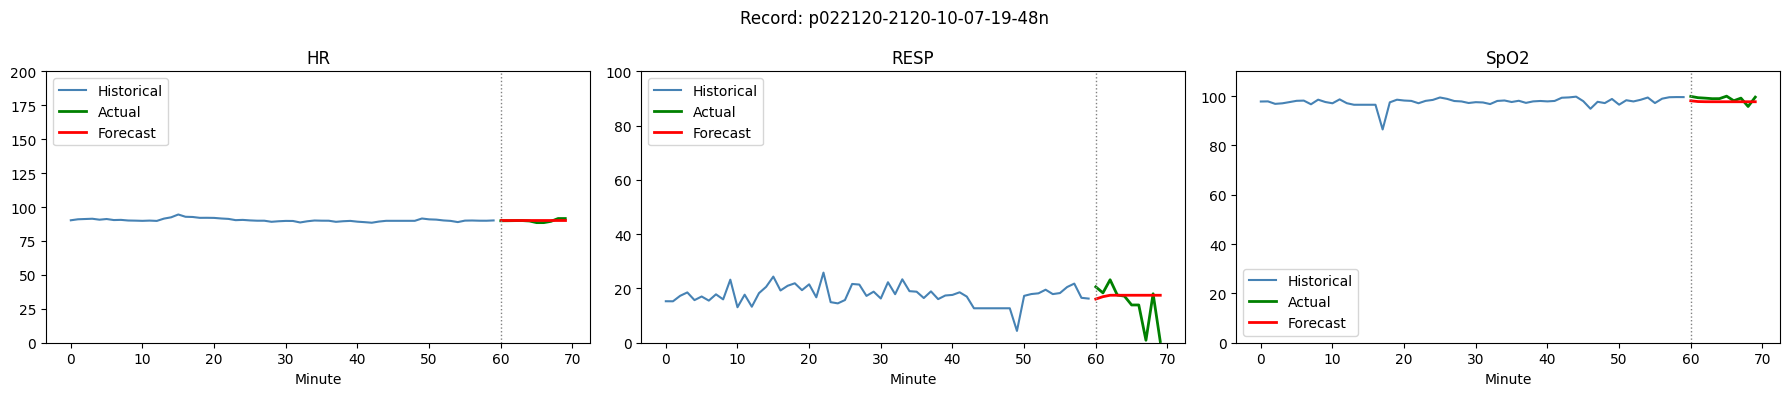

  p023097-2184-12-09-12-34n | HR | order=(0, 1, 1) | MAE=0.852 | MAPE=1.179 | RMSE=0.991
  p023097-2184-12-09-12-34n | RESP | order=(1, 1, 1) | MAE=1.947 | MAPE=11.235 | RMSE=2.702
  p023097-2184-12-09-12-34n | SpO2 | order=(0, 1, 0) | MAE=0.520 | MAPE=0.553 | RMSE=0.653


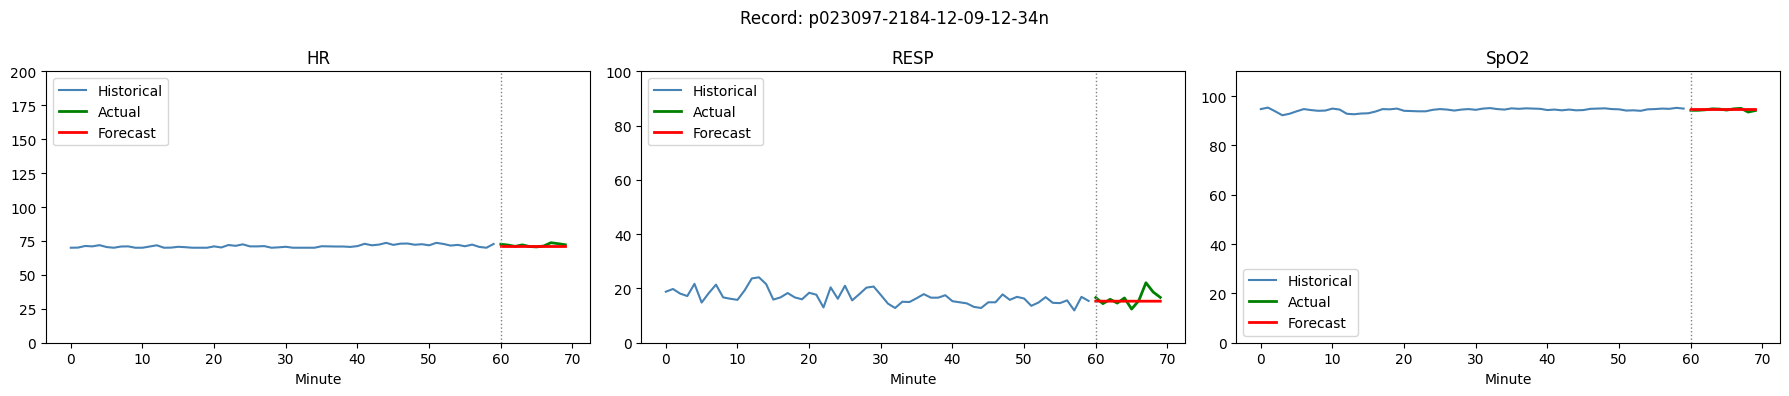

  p024508-2195-10-26-19-08n | HR | order=(1, 1, 0) | MAE=0.424 | MAPE=0.554 | RMSE=0.542
  p024508-2195-10-26-19-08n | RESP | order=(2, 0, 0) | MAE=21.536 | MAPE=88.707 | RMSE=23.193
  p024508-2195-10-26-19-08n | SpO2 | order=(0, 1, 1) | MAE=0.656 | MAPE=0.669 | RMSE=0.667


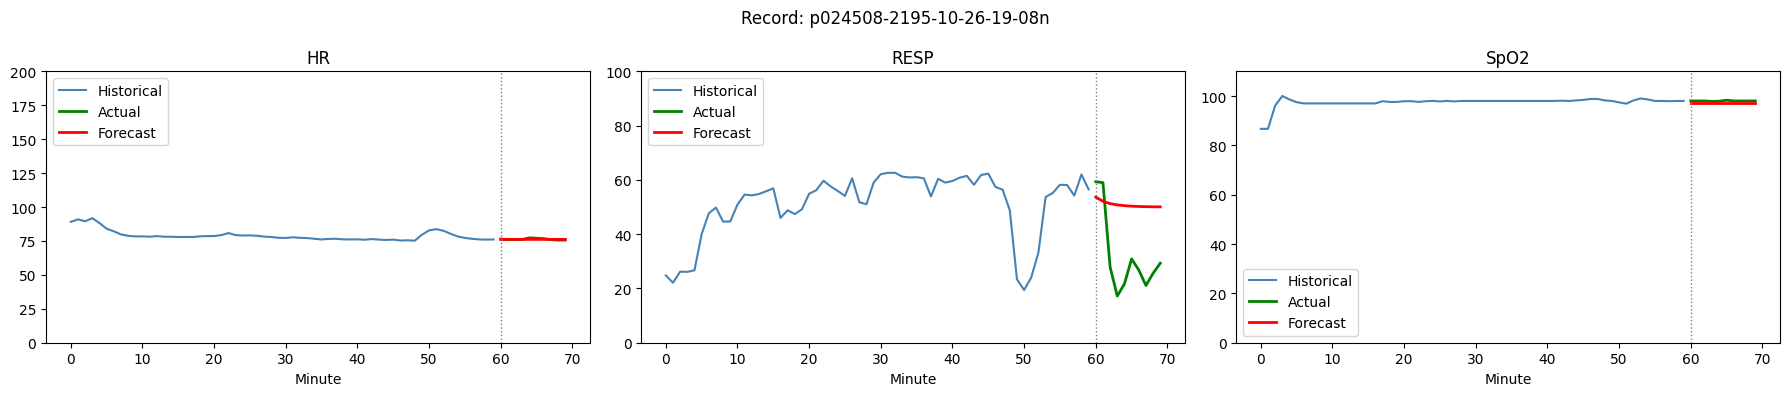

  p025757-2199-04-01-20-01n | HR | order=(1, 0, 0) | MAE=0.563 | MAPE=0.624 | RMSE=0.672
  p025757-2199-04-01-20-01n | RESP | order=(3, 0, 0) | MAE=2.433 | MAPE=35.203 | RMSE=2.557
  p025757-2199-04-01-20-01n | SpO2 | order=(1, 0, 0) | MAE=0.381 | MAPE=0.388 | RMSE=0.449


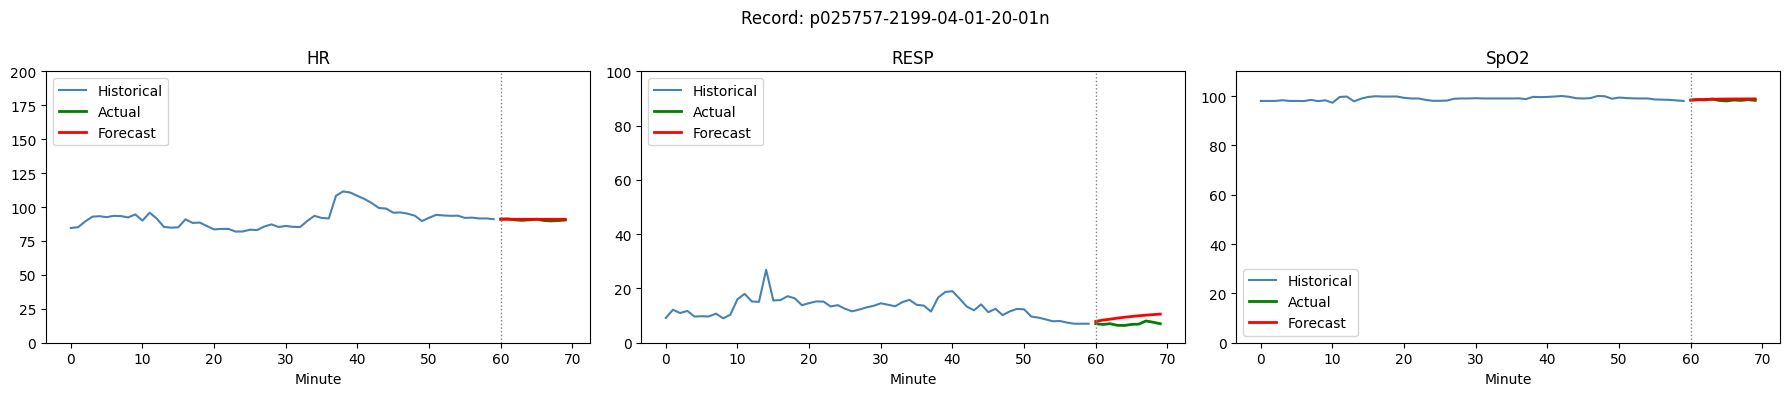

  p026711-2113-07-07-12-22n | HR | order=(3, 1, 0) | MAE=8.681 | MAPE=7.246 | RMSE=9.506
  p026711-2113-07-07-12-22n | RESP | order=(1, 0, 0) | MAE=1.505 | MAPE=6.517 | RMSE=1.938
  p026711-2113-07-07-12-22n | SpO2 | order=(0, 1, 0) | MAE=1.560 | MAPE=1.581 | RMSE=1.575


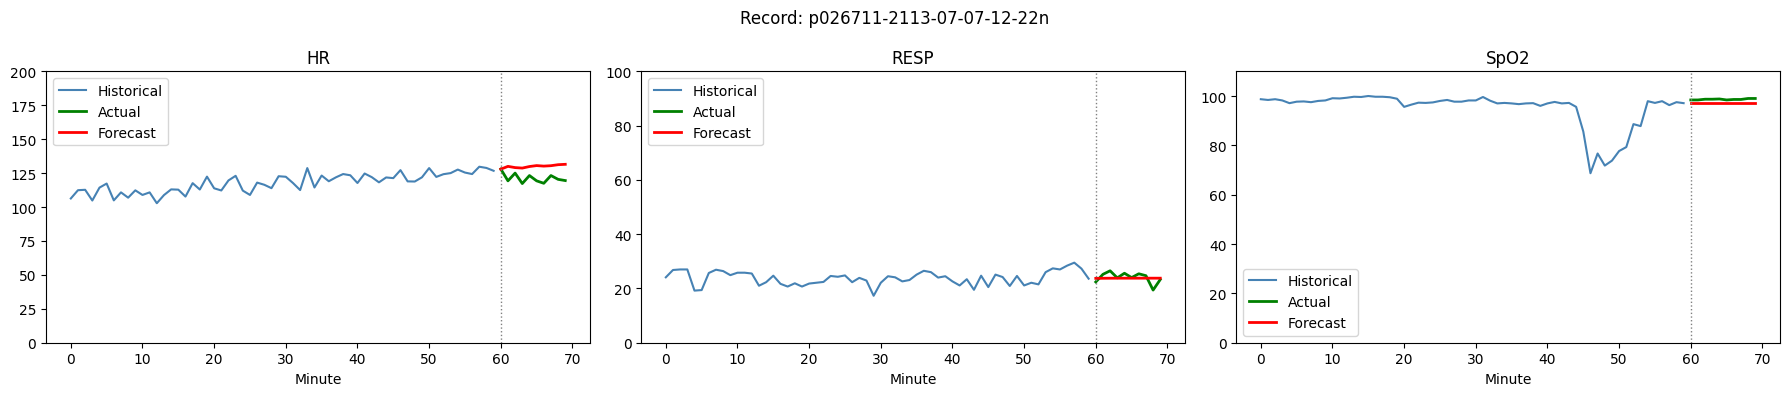

  p028281-2125-12-22-01-46n | HR | order=(2, 2, 1) | MAE=6.684 | MAPE=5.642 | RMSE=7.595
  p028281-2125-12-22-01-46n | RESP | order=(0, 1, 1) | MAE=1.711 | MAPE=6.699 | RMSE=2.043
  p028281-2125-12-22-01-46n | SpO2 | order=(0, 1, 0) | MAE=0.163 | MAPE=0.166 | RMSE=0.193


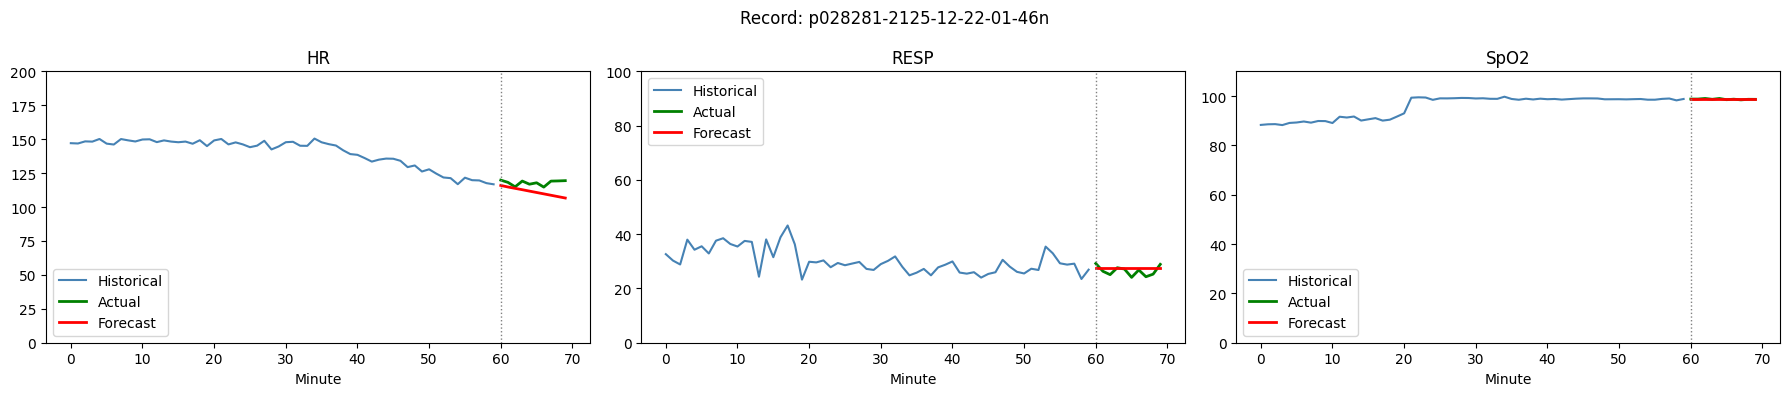

  p030047-2154-02-15-16-48n | HR | order=(1, 1, 0) | MAE=0.124 | MAPE=0.144 | RMSE=0.175
  p030047-2154-02-15-16-48n | RESP | order=(0, 0, 0) | MAE=1.605 | MAPE=6.874 | RMSE=1.897
  p030047-2154-02-15-16-48n | SpO2 | order=(0, 0, 0) | MAE=0.454 | MAPE=0.454 | RMSE=0.456


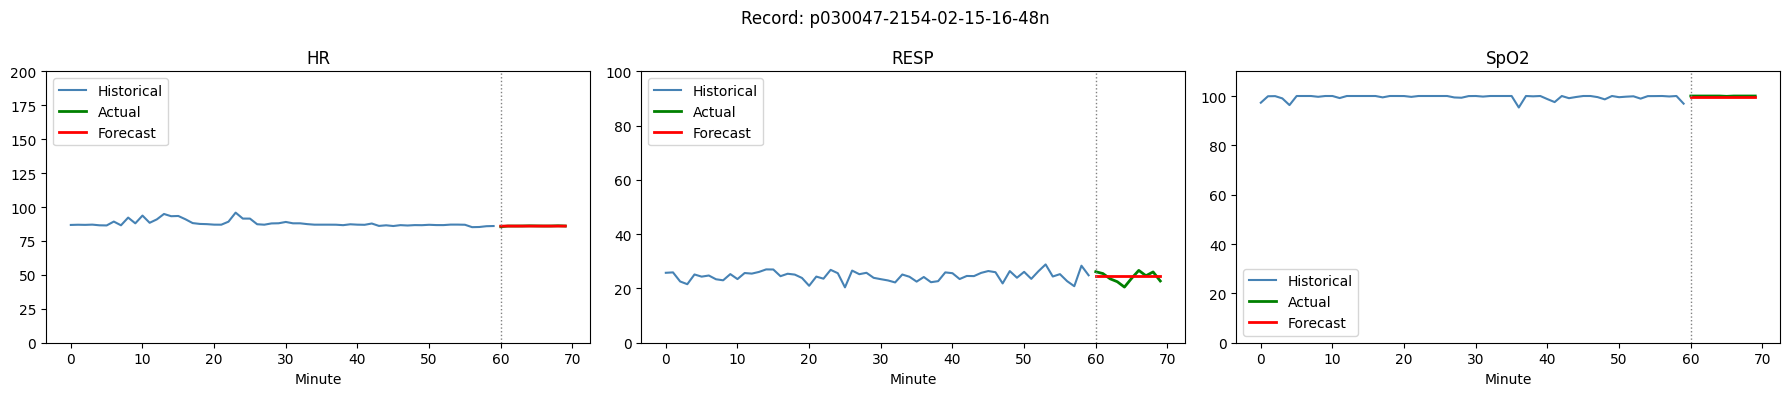

  p032247-2122-01-20-15-13n | HR | order=(2, 1, 2) | MAE=1.822 | MAPE=1.593 | RMSE=2.192
  p032247-2122-01-20-15-13n | RESP | order=(1, 1, 0) | MAE=2.356 | MAPE=7.147 | RMSE=2.957
  p032247-2122-01-20-15-13n | SpO2 | order=(0, 1, 0) | MAE=1.340 | MAPE=1.349 | RMSE=1.422


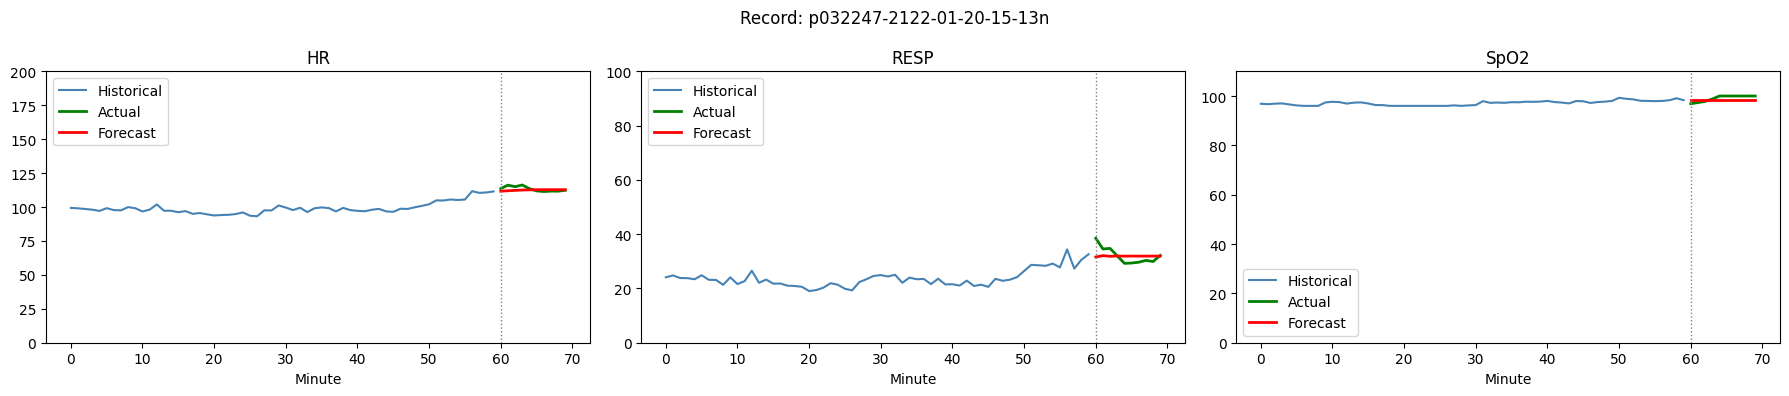

  p041768-2116-06-29-20-18n | HR | order=(0, 1, 0) | MAE=6.227 | MAPE=10.520 | RMSE=7.155
  p041768-2116-06-29-20-18n | RESP | order=(1, 0, 0) | MAE=0.860 | MAPE=5.080 | RMSE=1.353
  p041768-2116-06-29-20-18n | SpO2 | order=(1, 0, 0) | MAE=0.484 | MAPE=0.497 | RMSE=0.561


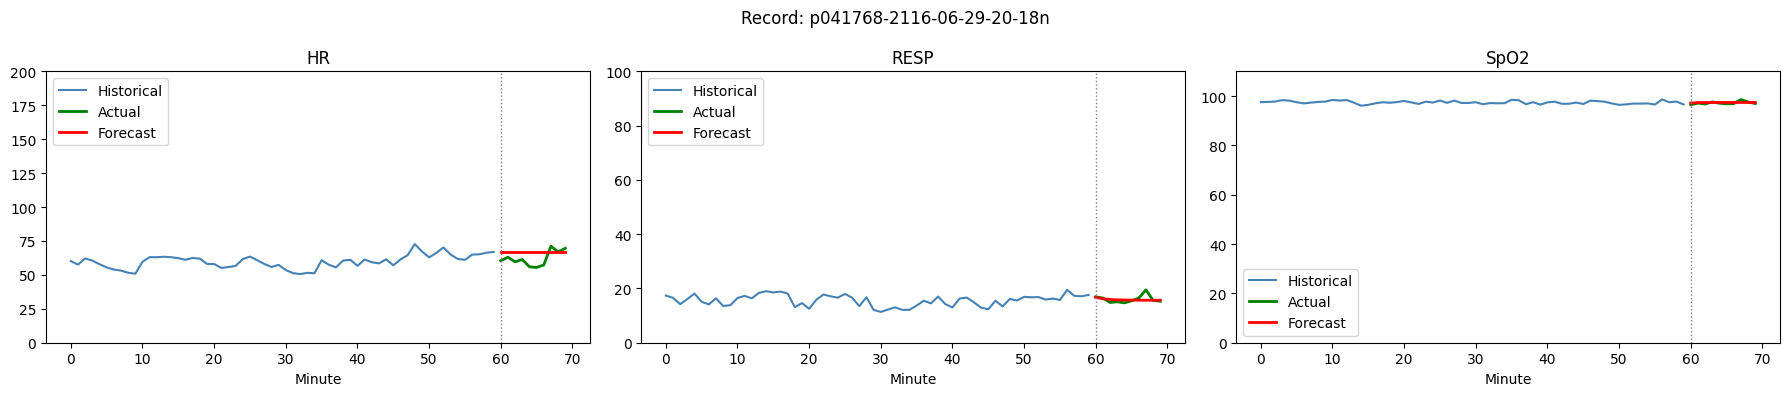

  p044255-2145-09-29-13-40n | HR | order=(0, 1, 2) | MAE=0.655 | MAPE=0.722 | RMSE=0.889
  p044255-2145-09-29-13-40n | RESP | order=(0, 0, 0) | MAE=1.969 | MAPE=8.750 | RMSE=2.455
  p044255-2145-09-29-13-40n | SpO2 | order=(5, 1, 0) | MAE=0.933 | MAPE=0.942 | RMSE=1.044


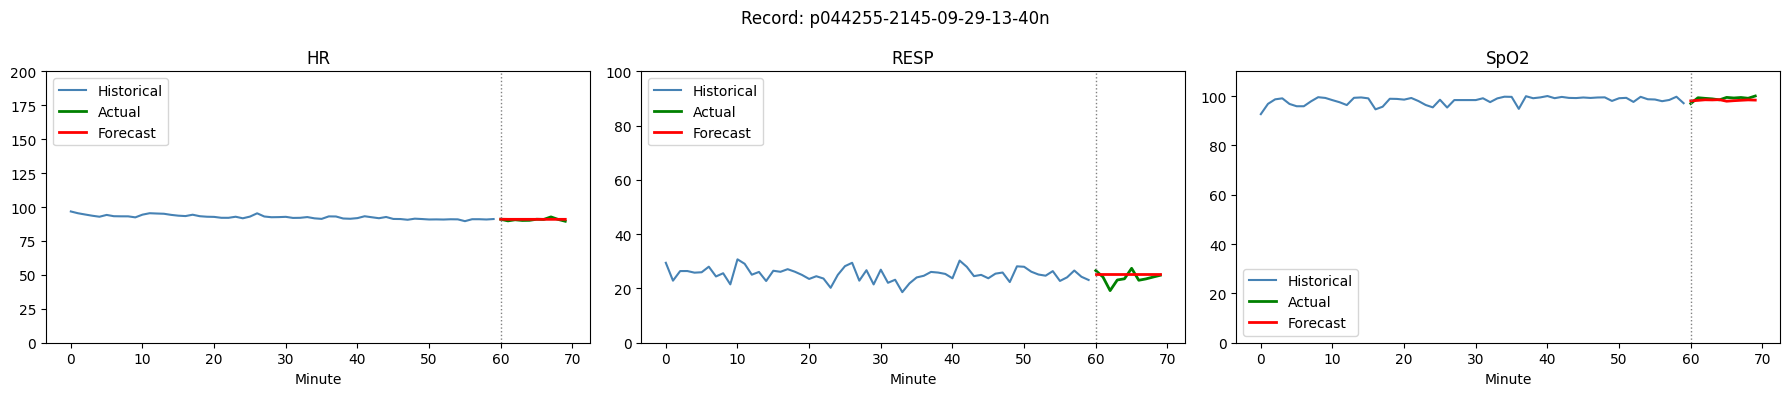

  p046695-2113-06-24-01-55n | HR | order=(0, 0, 1) | MAE=1.523 | MAPE=2.579 | RMSE=2.920
  p046695-2113-06-24-01-55n | RESP | order=(1, 0, 0) | MAE=1.101 | MAPE=7.018 | RMSE=1.874
  p046695-2113-06-24-01-55n | SpO2 | order=(0, 1, 0) | MAE=0.115 | MAPE=0.120 | RMSE=0.247


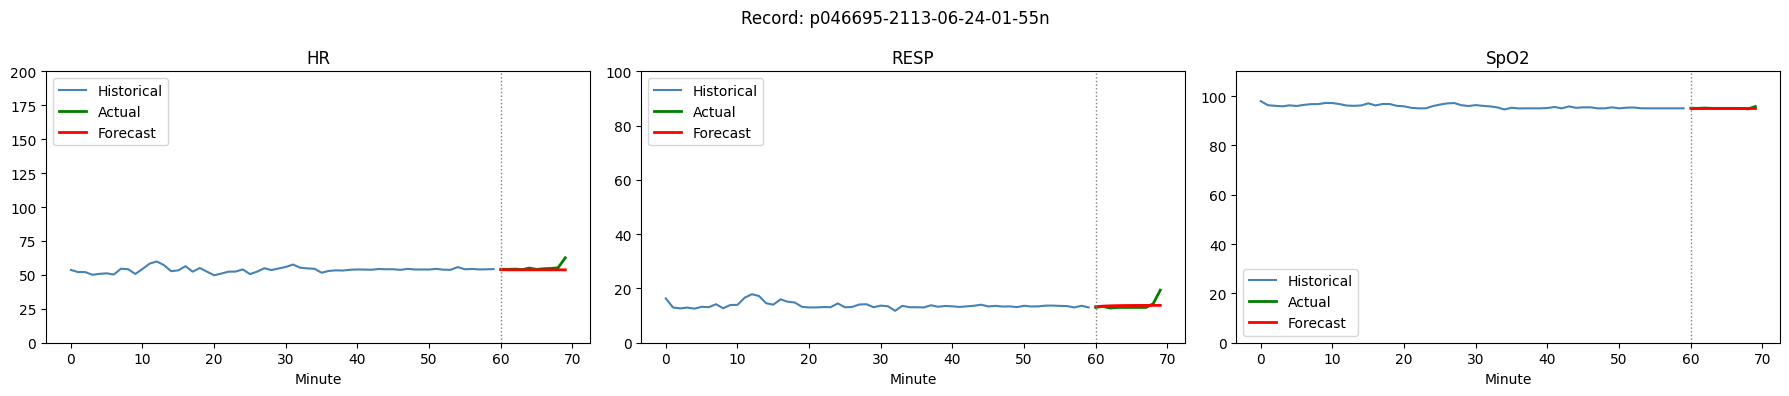

  p049649-2113-05-17-13-02n | HR | order=(1, 0, 0) | MAE=2.206 | MAPE=3.638 | RMSE=3.054
  p049649-2113-05-17-13-02n | RESP | order=(0, 1, 2) | MAE=0.503 | MAPE=3.554 | RMSE=0.556
  p049649-2113-05-17-13-02n | SpO2 | order=(3, 1, 0) | MAE=0.771 | MAPE=0.785 | RMSE=0.863


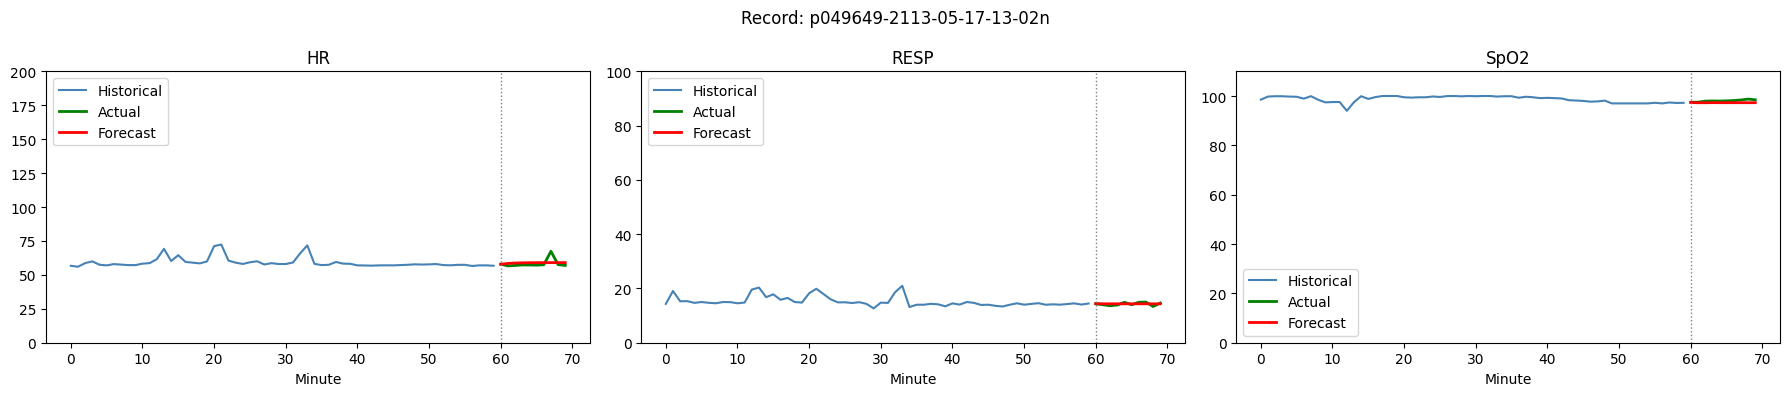

  p052191-2193-11-24-02-42n | HR | order=(1, 0, 1) | MAE=3.261 | MAPE=4.080 | RMSE=3.499
  p052191-2193-11-24-02-42n | RESP | order=(1, 1, 1) | MAE=0.297 | MAPE=1.486 | RMSE=0.298
  p052191-2193-11-24-02-42n | SpO2 | order=(0, 0, 0) | MAE=0.083 | MAPE=0.083 | RMSE=0.083


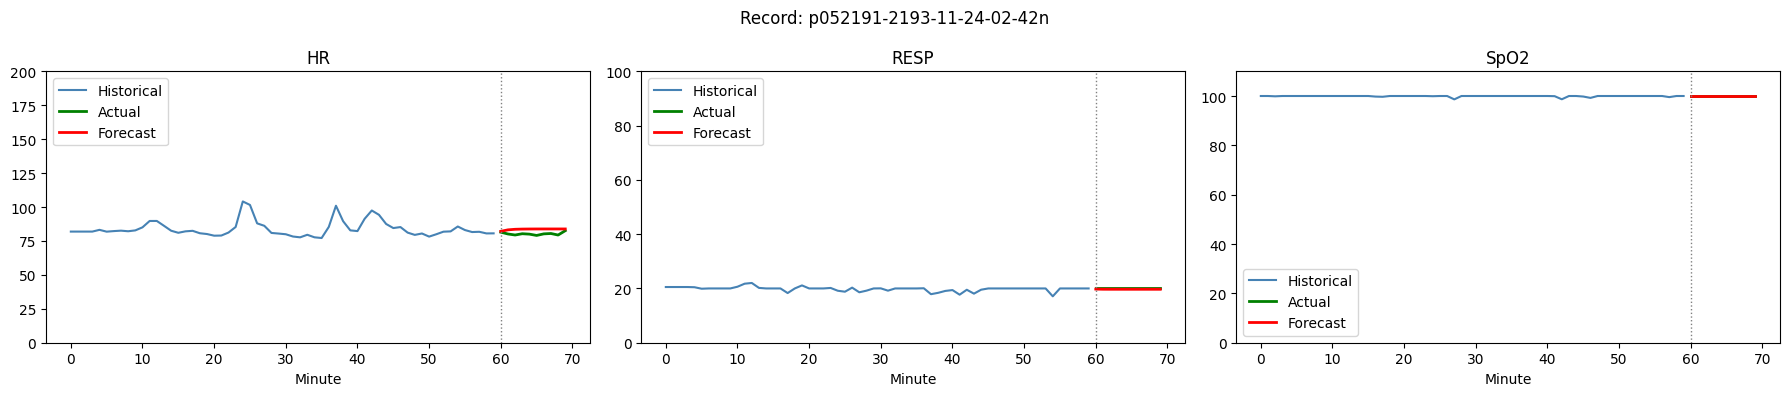

  p055332-2193-03-27-15-40n | HR | order=(1, 0, 0) | MAE=1.065 | MAPE=1.377 | RMSE=1.197
  p055332-2193-03-27-15-40n | RESP | order=(3, 1, 3) | MAE=1.789 | MAPE=7.924 | RMSE=2.153
  p055332-2193-03-27-15-40n | SpO2 | order=(0, 1, 2) | MAE=0.418 | MAPE=0.432 | RMSE=0.510


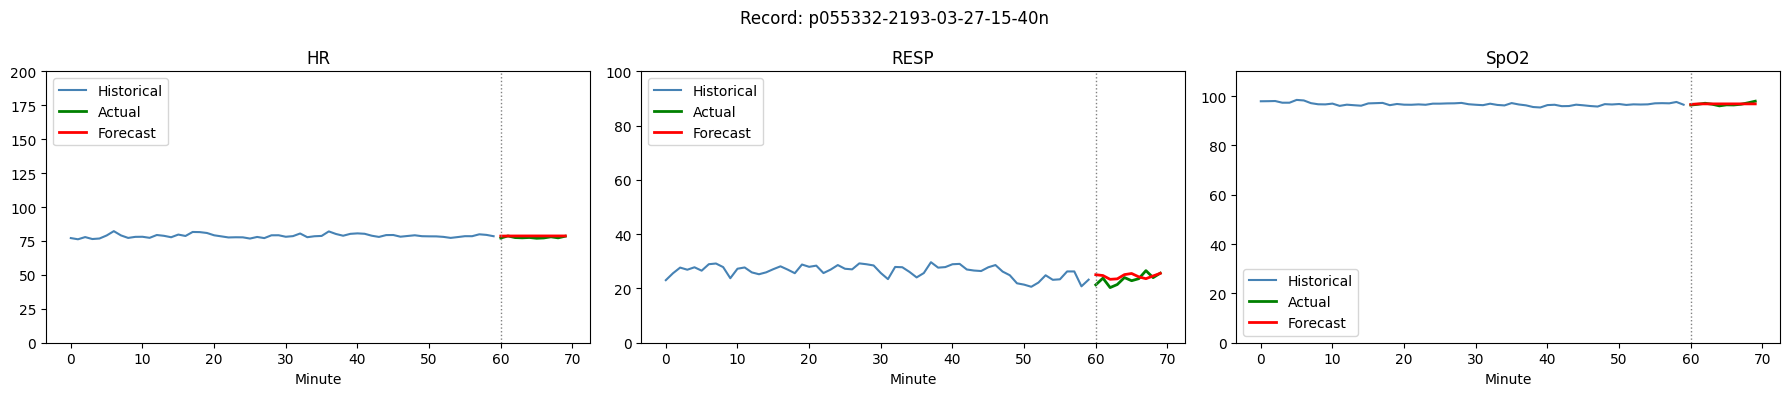

  p058662-2120-01-08-20-54n | HR | order=(2, 1, 0) | MAE=0.714 | MAPE=0.589 | RMSE=1.011
  p058662-2120-01-08-20-54n | RESP | order=(0, 1, 0) | MAE=0.640 | MAPE=2.121 | RMSE=0.724
  p058662-2120-01-08-20-54n | SpO2 | order=(1, 0, 0) | MAE=1.462 | MAPE=1.541 | RMSE=1.576


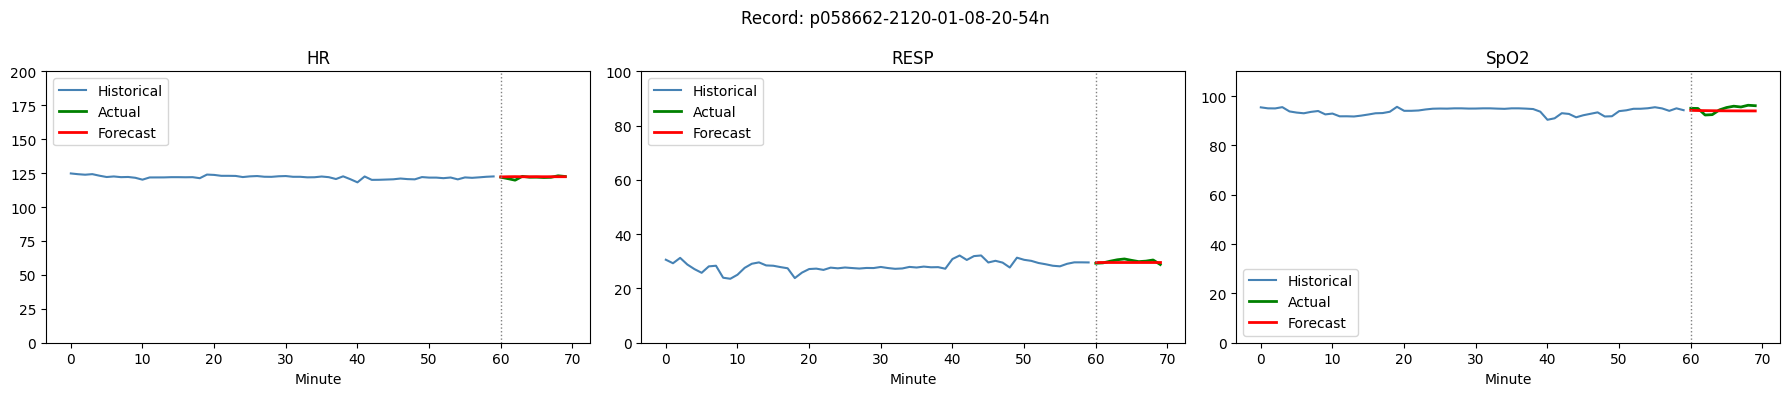

  p060226-2184-04-09-16-25n | HR | order=(0, 1, 0) | MAE=2.998 | MAPE=3.977 | RMSE=3.487
  p060226-2184-04-09-16-25n | RESP | order=(2, 1, 2) | MAE=0.174 | MAPE=1.425 | RMSE=0.211
  p060226-2184-04-09-16-25n | SpO2 | order=(0, 1, 1) | MAE=0.396 | MAPE=0.398 | RMSE=0.492


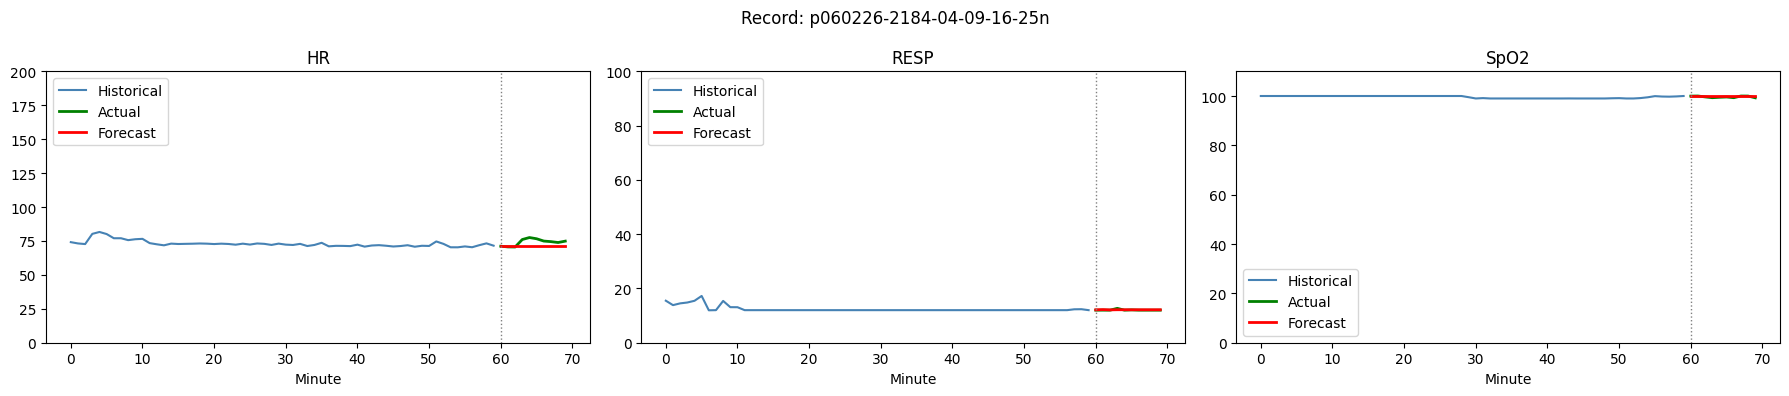

  p062647-2143-06-03-14-10n | HR | order=(0, 1, 0) | MAE=1.060 | MAPE=1.260 | RMSE=1.255
  p062647-2143-06-03-14-10n | RESP | order=(1, 0, 0) | MAE=1.141 | MAPE=6.447 | RMSE=1.285
  p062647-2143-06-03-14-10n | SpO2 | order=(0, 1, 0) | MAE=0.715 | MAPE=0.756 | RMSE=0.780


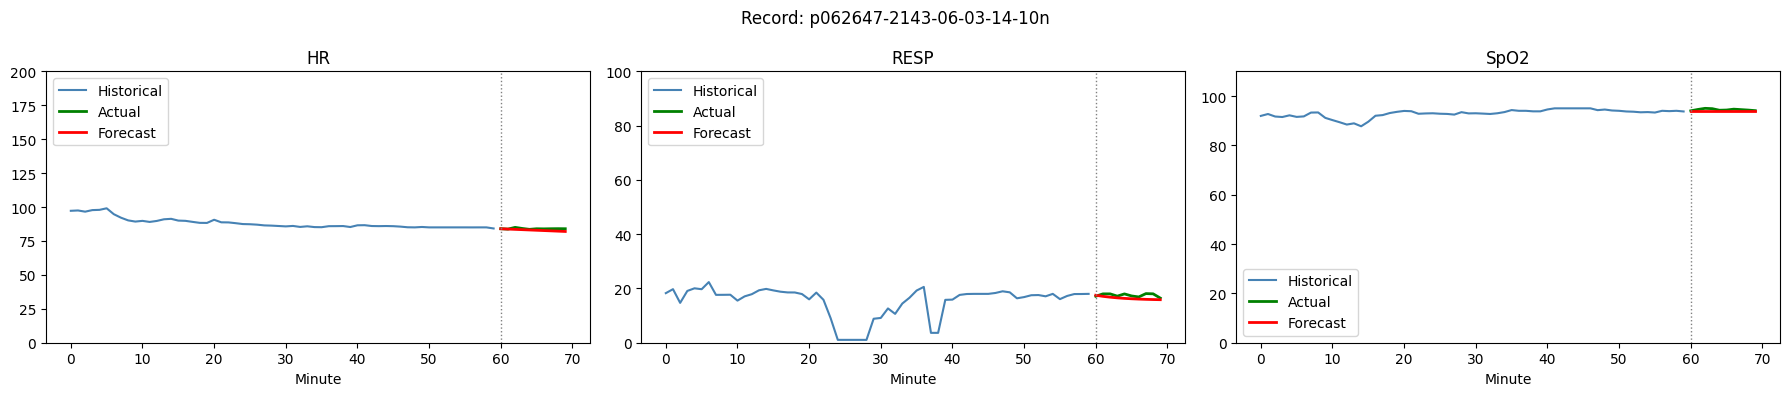

  p064361-2181-01-18-05-00n | HR | order=(0, 1, 4) | MAE=1.250 | MAPE=1.451 | RMSE=1.788
  p064361-2181-01-18-05-00n | RESP | order=(1, 0, 0) | MAE=10.190 | MAPE=551.359 | RMSE=11.307
  p064361-2181-01-18-05-00n | SpO2 | order=(1, 0, 0) | MAE=1.127 | MAPE=1.131 | RMSE=1.213


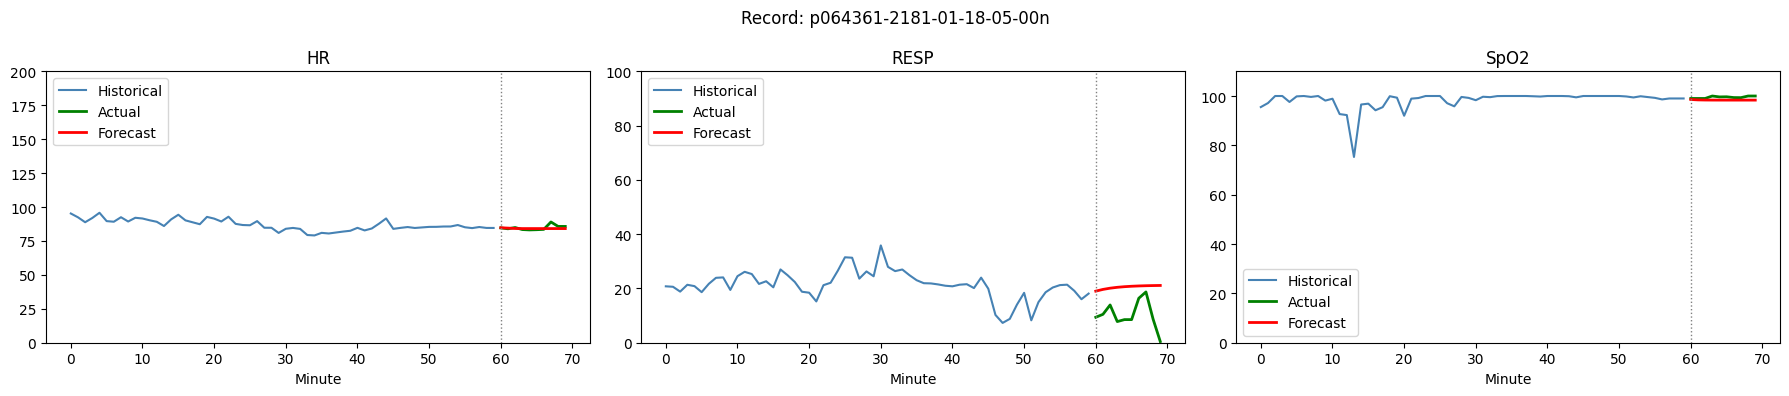

  p066786-2119-08-19-13-12n | HR | order=(0, 0, 1) | MAE=2.455 | MAPE=2.730 | RMSE=2.948
  p066786-2119-08-19-13-12n | RESP | order=(0, 1, 2) | MAE=6.195 | MAPE=56.288 | RMSE=6.782
  p066786-2119-08-19-13-12n | SpO2 | order=(0, 0, 1) | MAE=1.414 | MAPE=1.417 | RMSE=1.462


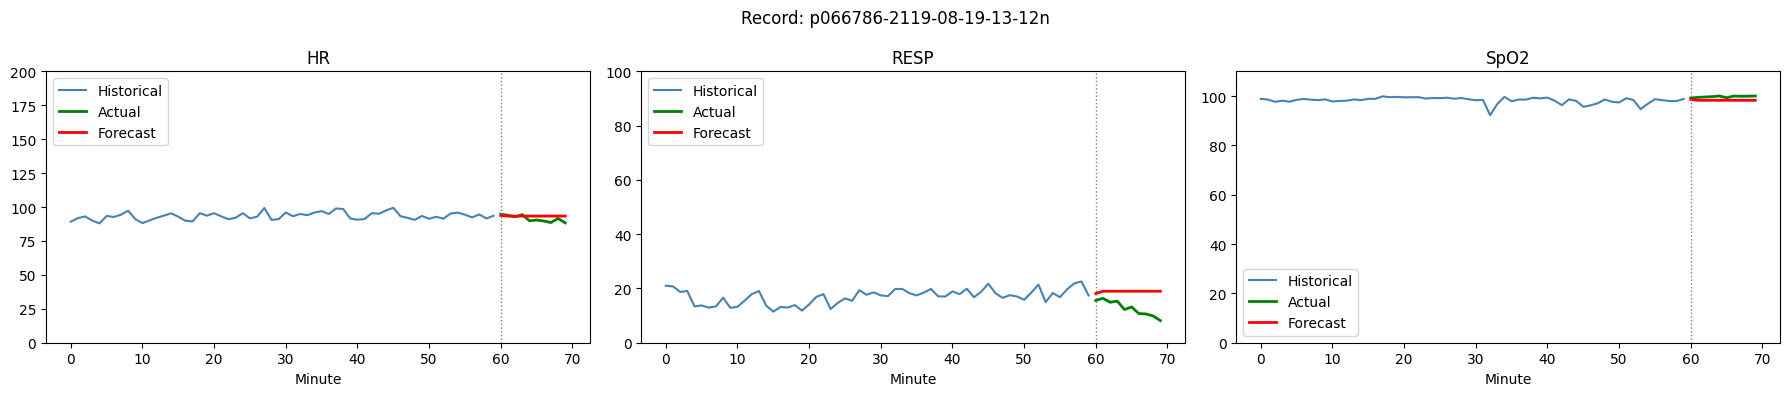

  p068736-2113-12-08-10-43n | HR | order=(0, 1, 0) | MAE=1.010 | MAPE=1.286 | RMSE=1.075
  p068736-2113-12-08-10-43n | RESP | order=(0, 0, 1) | MAE=2.129 | MAPE=13.098 | RMSE=2.326
  p068736-2113-12-08-10-43n | SpO2 | order=(1, 0, 0) | MAE=0.803 | MAPE=0.847 | RMSE=1.066


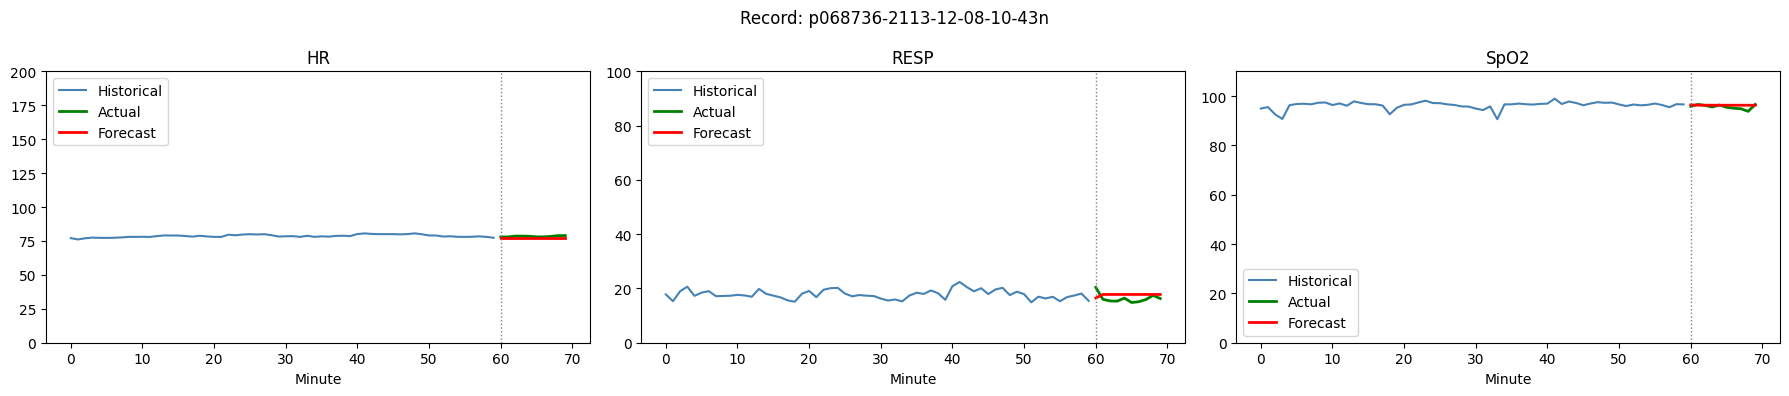

  p071707-2144-01-21-10-52n | HR | order=(1, 0, 1) | MAE=2.557 | MAPE=4.326 | RMSE=2.667
  p071707-2144-01-21-10-52n | RESP | order=(1, 0, 0) | MAE=1.289 | MAPE=8.994 | RMSE=1.594
  p071707-2144-01-21-10-52n | SpO2 | order=(1, 0, 0) | MAE=0.998 | MAPE=1.024 | RMSE=1.180


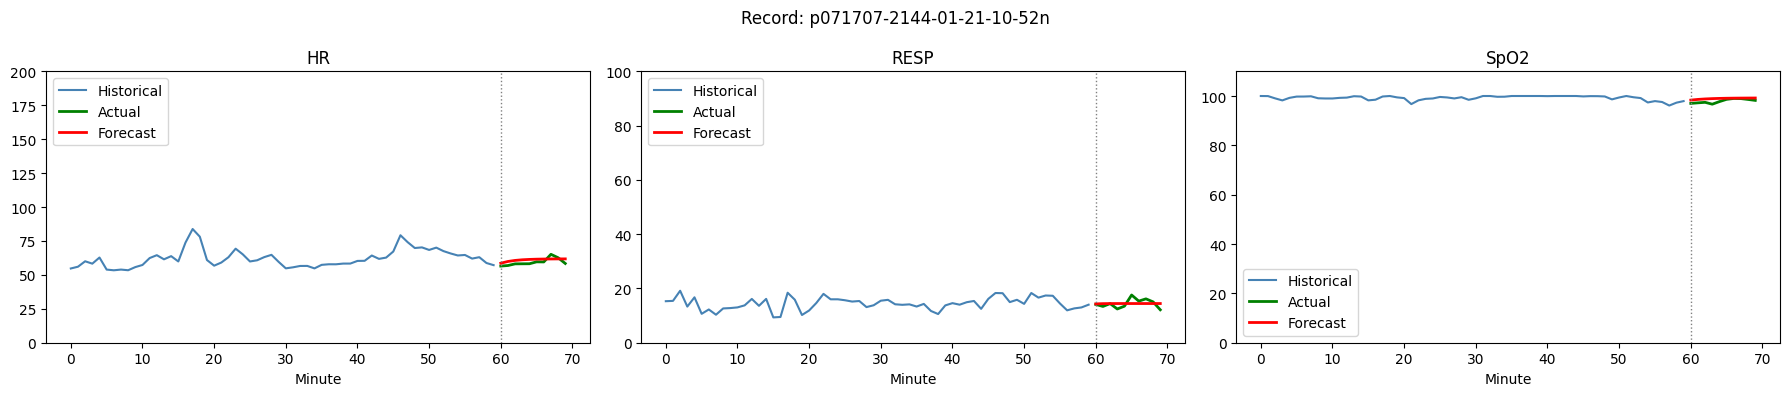

  p074397-2177-04-06-21-28n | HR | order=(3, 1, 0) | MAE=1.370 | MAPE=1.701 | RMSE=1.682
  p074397-2177-04-06-21-28n | RESP | order=(0, 0, 1) | MAE=3.613 | MAPE=27.651 | RMSE=4.375
  p074397-2177-04-06-21-28n | SpO2 | order=(0, 1, 0) | MAE=0.463 | MAPE=0.473 | RMSE=0.565


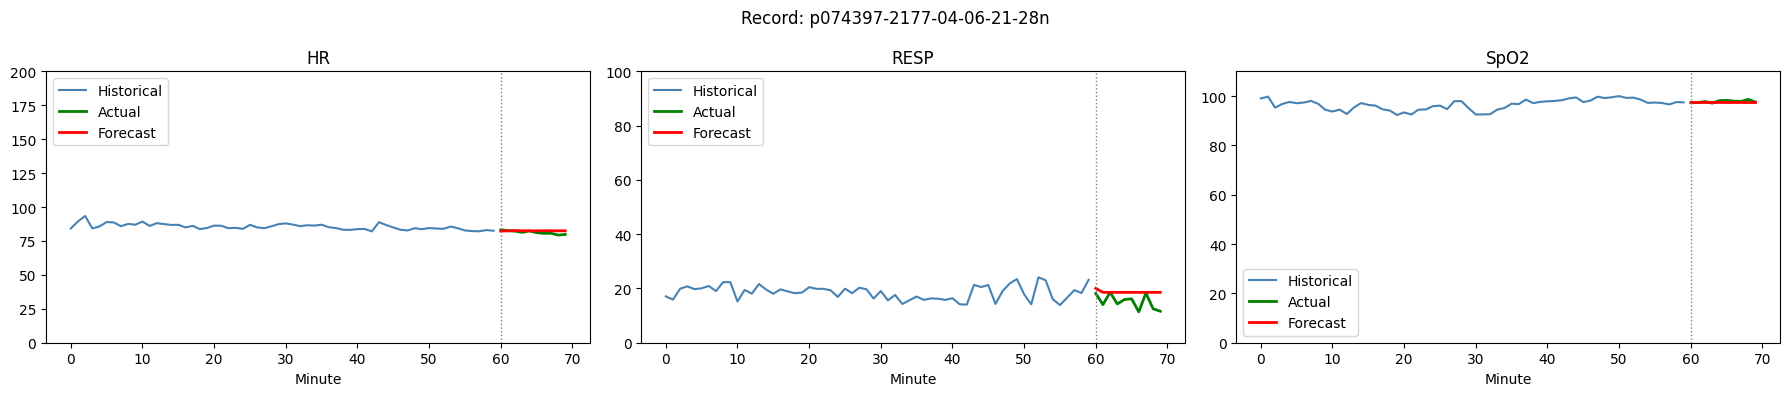

  p076028-2118-10-16-22-52n | HR | order=(3, 1, 0) | MAE=1.674 | MAPE=2.797 | RMSE=1.766
  p076028-2118-10-16-22-52n | RESP | order=(0, 1, 1) | MAE=0.000 | MAPE=0.002 | RMSE=0.000
  p076028-2118-10-16-22-52n | SpO2 | order=(0, 0, 1) | MAE=0.008 | MAPE=0.008 | RMSE=0.008


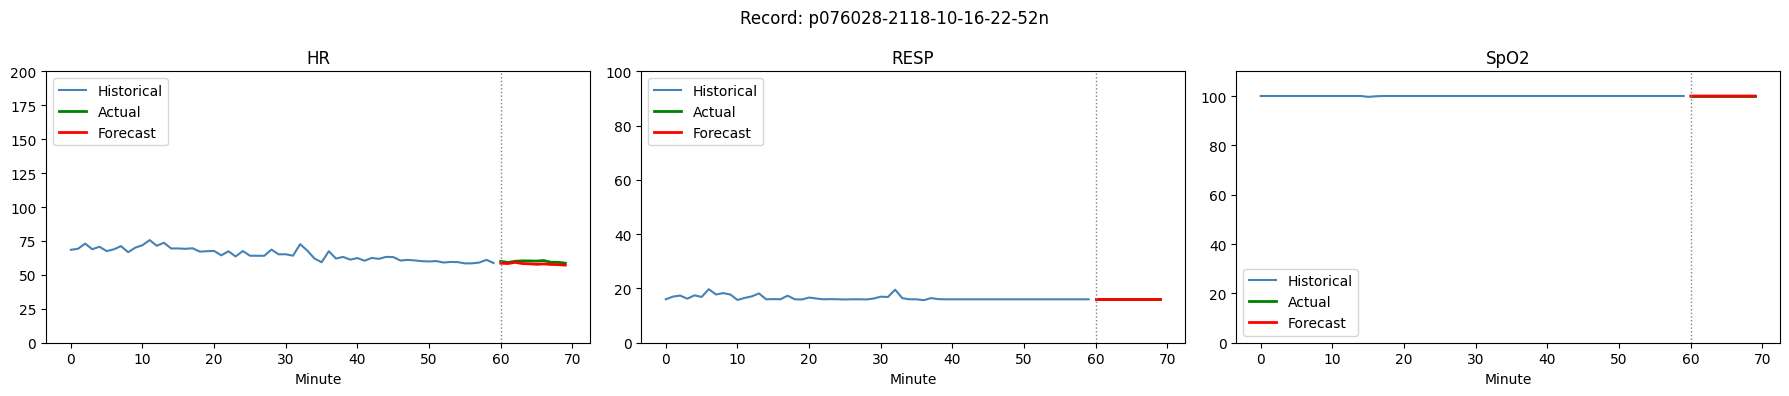

  p078506-2133-11-12-13-56n | HR | order=(0, 1, 1) | MAE=1.207 | MAPE=1.325 | RMSE=1.395
  p078506-2133-11-12-13-56n | RESP | order=(1, 0, 0) | MAE=8.141 | MAPE=25.734 | RMSE=10.621
  p078506-2133-11-12-13-56n | SpO2 | order=(1, 0, 0) | MAE=0.292 | MAPE=0.295 | RMSE=0.391


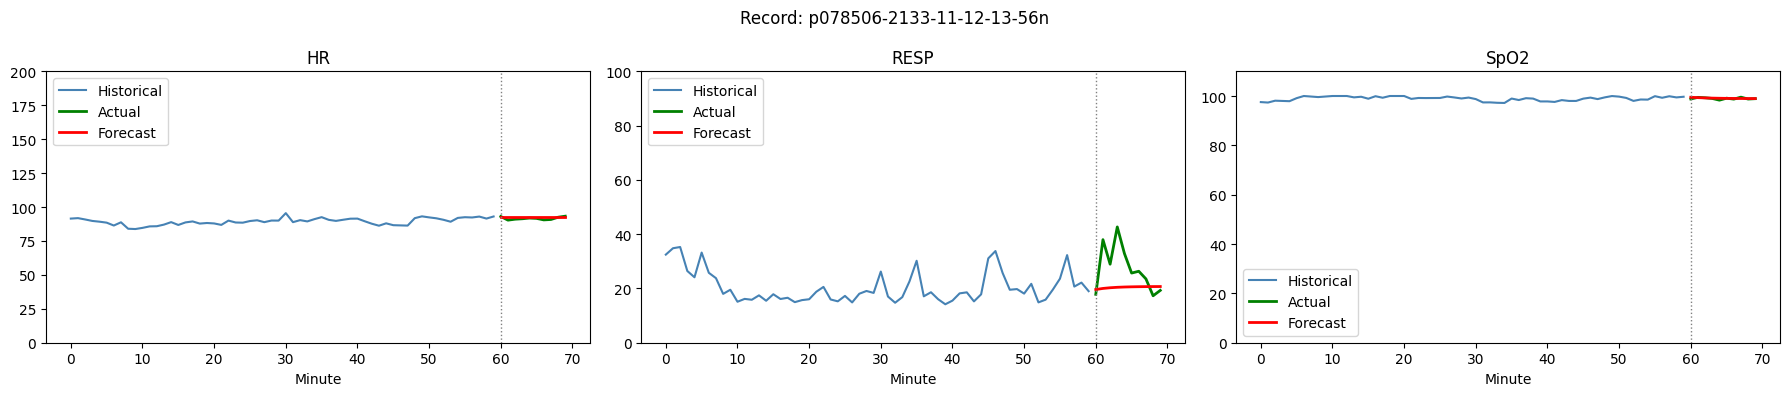

  p081166-2103-12-18-18-01n | HR | order=(2, 0, 0) | MAE=4.654 | MAPE=4.966 | RMSE=4.883
  p081166-2103-12-18-18-01n | RESP | order=(0, 0, 0) | MAE=0.039 | MAPE=0.394 | RMSE=0.039
  p081166-2103-12-18-18-01n | SpO2 | order=(0, 0, 0) | MAE=0.115 | MAPE=0.118 | RMSE=0.205


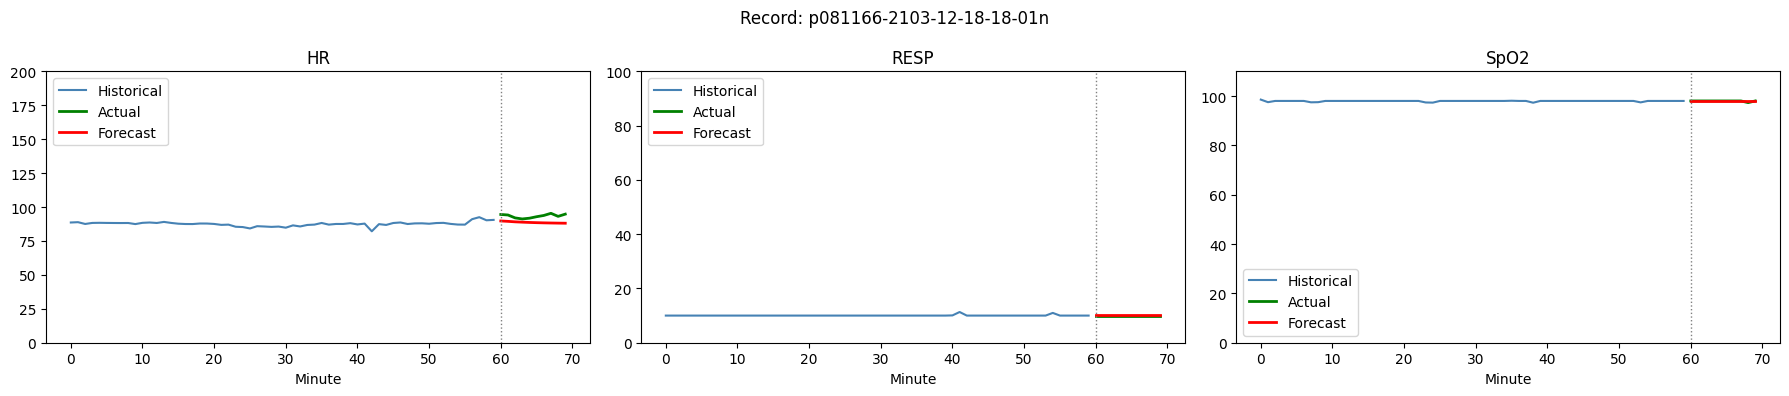

  p082759-2137-09-02-11-44n | HR | order=(1, 0, 0) | MAE=2.272 | MAPE=3.644 | RMSE=2.789
  p082759-2137-09-02-11-44n | RESP | order=(1, 0, 2) | MAE=1.059 | MAPE=6.162 | RMSE=1.273
  p082759-2137-09-02-11-44n | SpO2 | order=(1, 0, 0) | MAE=1.714 | MAPE=1.849 | RMSE=2.399


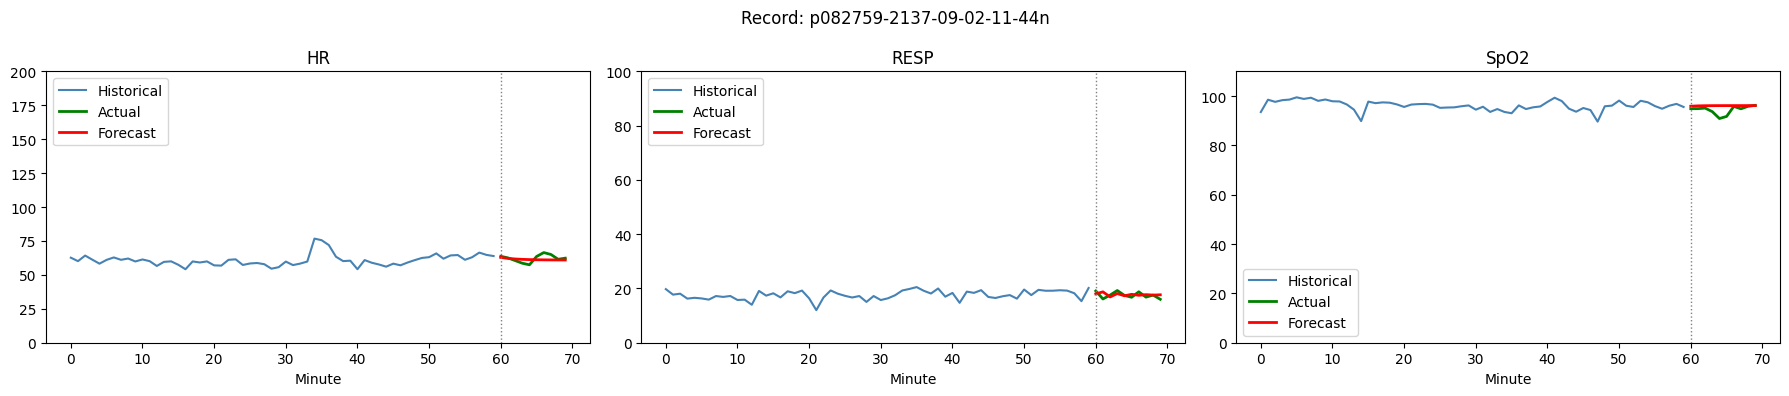

  p085205-2186-01-30-02-49n | HR | order=(2, 1, 0) | MAE=0.562 | MAPE=0.448 | RMSE=0.803
  p085205-2186-01-30-02-49n | RESP | order=(0, 1, 2) | MAE=0.529 | MAPE=3.707 | RMSE=0.608
  p085205-2186-01-30-02-49n | SpO2 | order=(1, 0, 0) | MAE=0.814 | MAPE=0.814 | RMSE=0.896


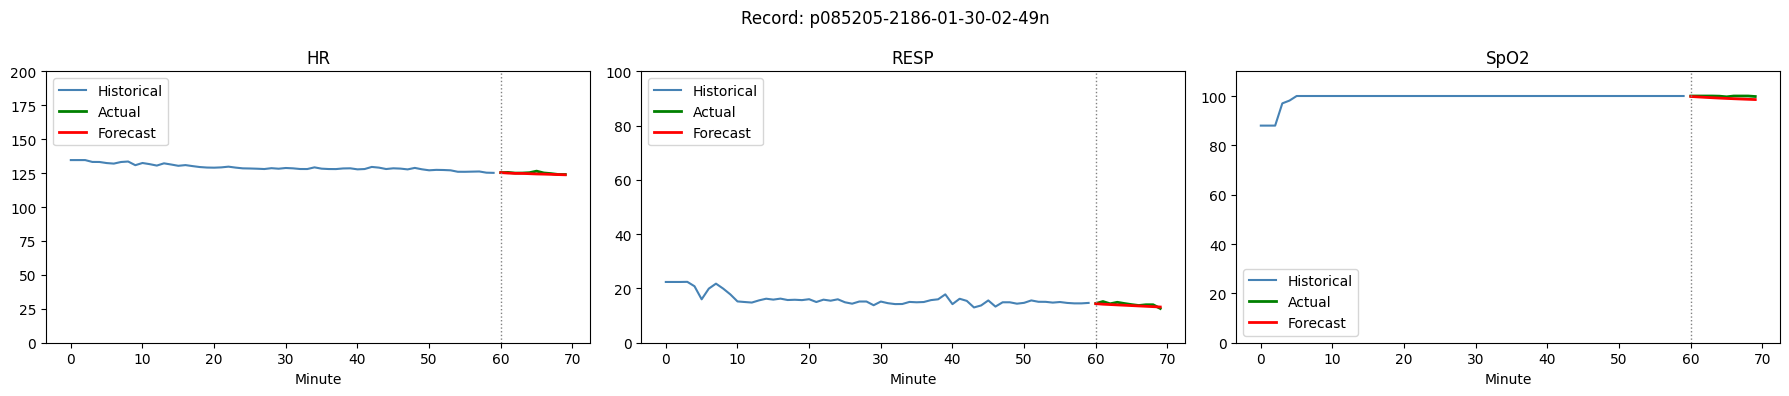

  p088164-2159-08-28-19-31n | HR | order=(1, 0, 0) | MAE=1.551 | MAPE=2.113 | RMSE=1.784
  p088164-2159-08-28-19-31n | RESP | order=(1, 0, 0) | MAE=2.325 | MAPE=11.657 | RMSE=2.880
  p088164-2159-08-28-19-31n | SpO2 | order=(0, 1, 0) | MAE=1.202 | MAPE=1.300 | RMSE=2.815


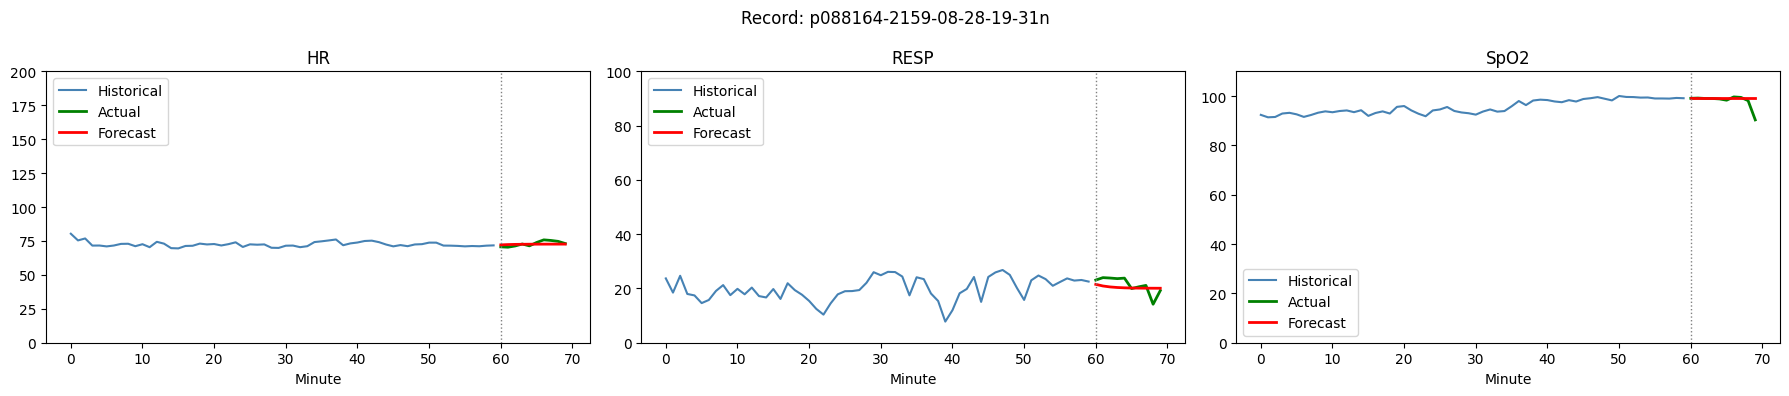

  p090198-2129-11-09-08-23n | HR | order=(1, 0, 0) | MAE=1.601 | MAPE=1.660 | RMSE=1.621
  p090198-2129-11-09-08-23n | RESP | order=(0, 0, 0) | MAE=1.718 | MAPE=11.944 | RMSE=1.843
  p090198-2129-11-09-08-23n | SpO2 | order=(1, 0, 0) | MAE=0.235 | MAPE=0.250 | RMSE=0.275


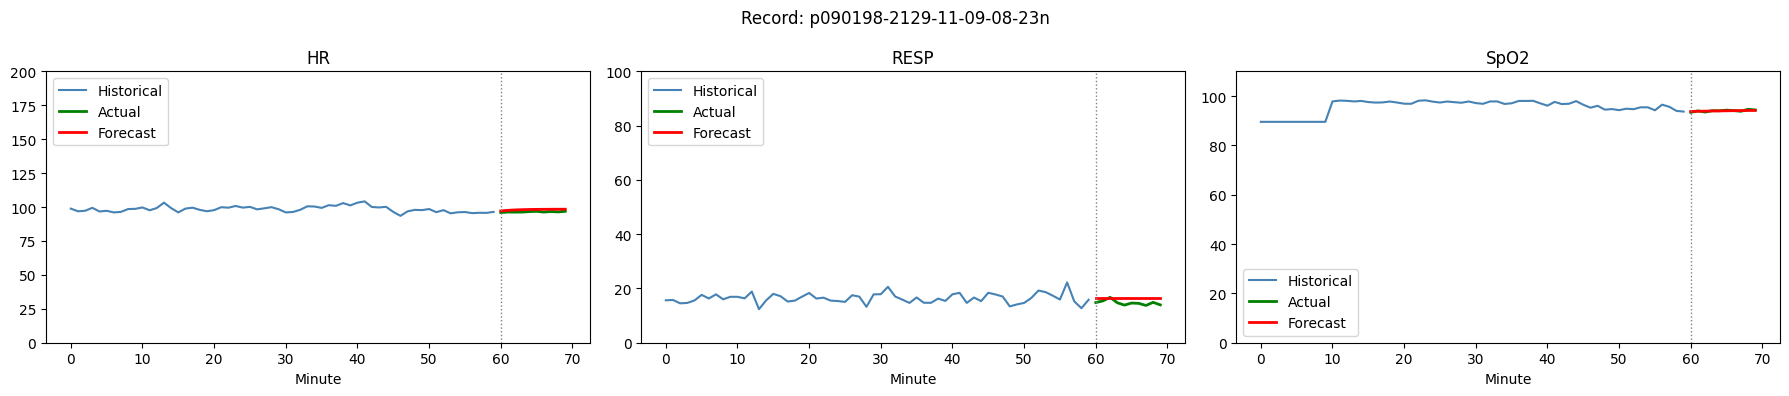

  p093301-2110-02-19-06-42n | HR | order=(1, 0, 0) | MAE=1.997 | MAPE=1.357 | RMSE=2.704
  p093301-2110-02-19-06-42n | RESP | order=(1, 0, 0) | MAE=1.336 | MAPE=5.872 | RMSE=1.614
  p093301-2110-02-19-06-42n | SpO2 | order=(0, 1, 0) | MAE=1.298 | MAPE=1.394 | RMSE=1.403


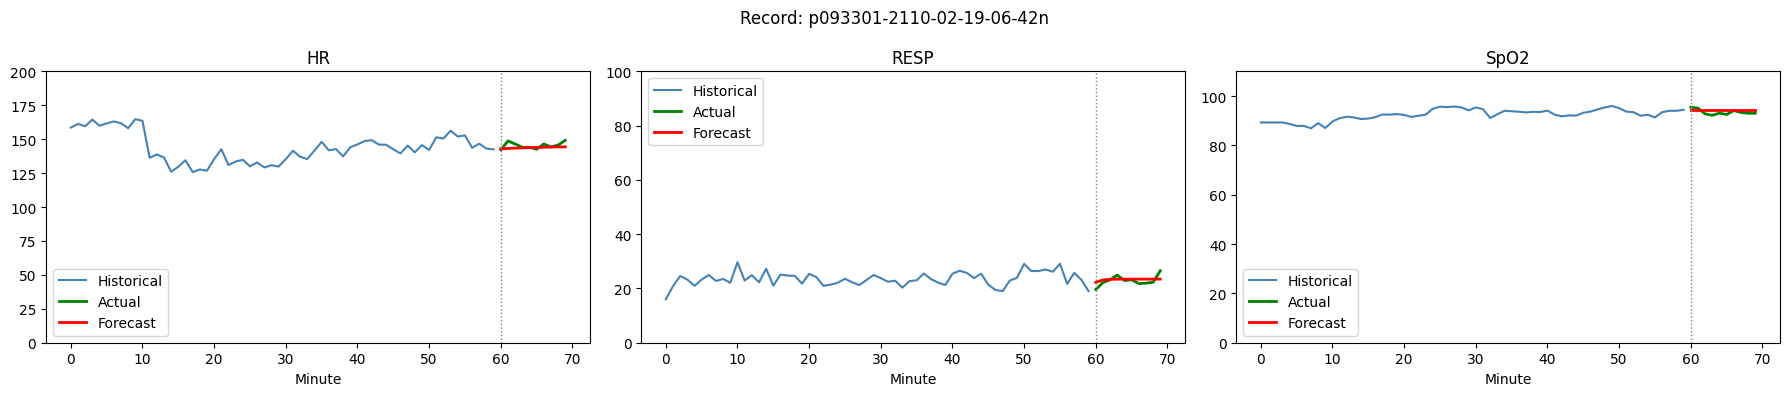

  p095088-2189-11-04-13-39n | HR | order=(1, 0, 0) | MAE=0.941 | MAPE=1.112 | RMSE=1.244
  p095088-2189-11-04-13-39n | RESP | order=(0, 0, 0) | MAE=0.264 | MAPE=1.126 | RMSE=0.363
  p095088-2189-11-04-13-39n | SpO2 | order=(0, 0, 0) | MAE=0.004 | MAPE=0.004 | RMSE=0.004


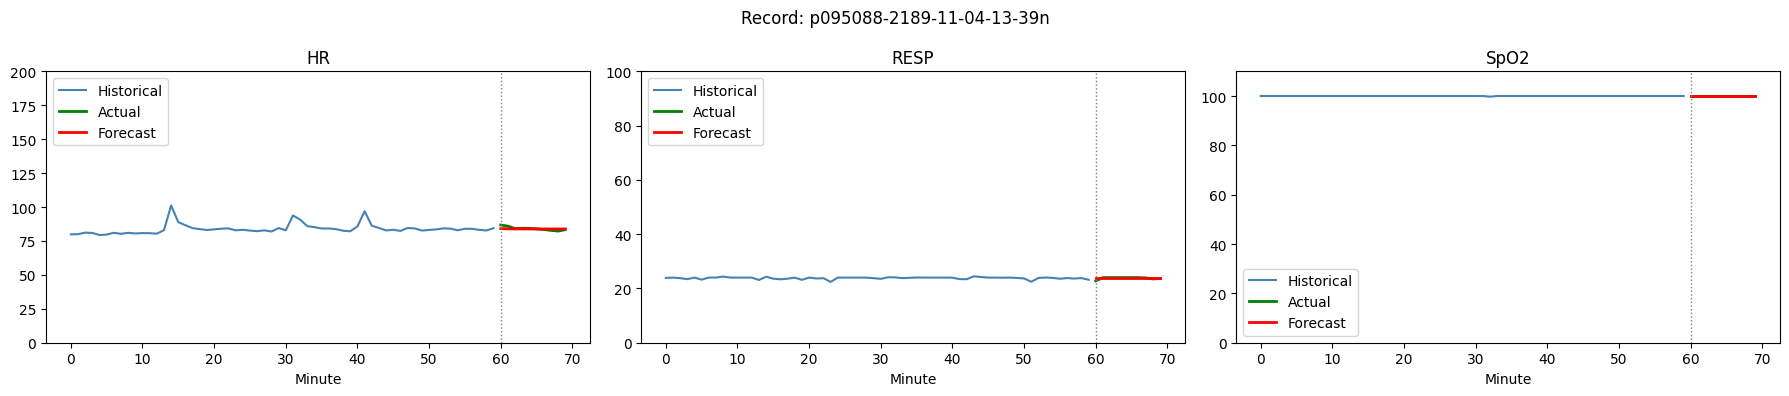

  p097151-2131-08-30-11-49n | HR | order=(0, 1, 1) | MAE=0.868 | MAPE=1.510 | RMSE=0.996
  p097151-2131-08-30-11-49n | RESP | order=(0, 1, 2) | MAE=1.148 | MAPE=7.254 | RMSE=1.222
  p097151-2131-08-30-11-49n | SpO2 | order=(0, 1, 0) | MAE=0.165 | MAPE=0.166 | RMSE=0.186


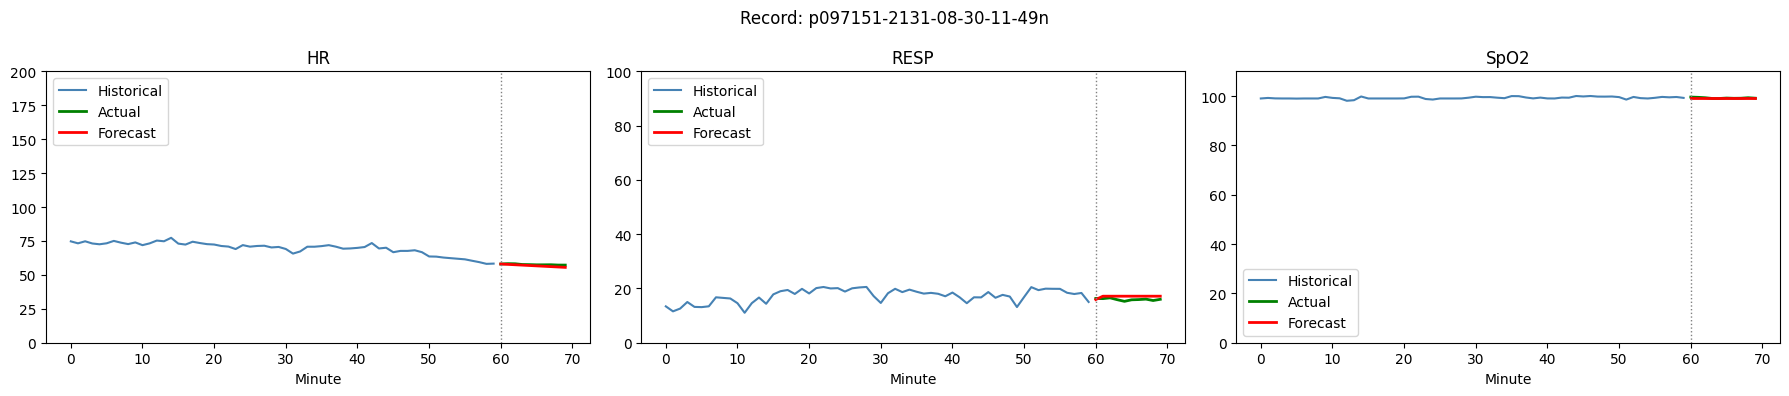

  p099983-2193-04-26-12-01n | HR | order=(0, 0, 0) | MAE=1.739 | MAPE=2.569 | RMSE=2.166
  p099983-2193-04-26-12-01n | RESP | order=(0, 0, 0) | MAE=1.215 | MAPE=6.675 | RMSE=1.681
  p099983-2193-04-26-12-01n | SpO2 | order=(0, 0, 0) | MAE=0.619 | MAPE=0.623 | RMSE=0.652


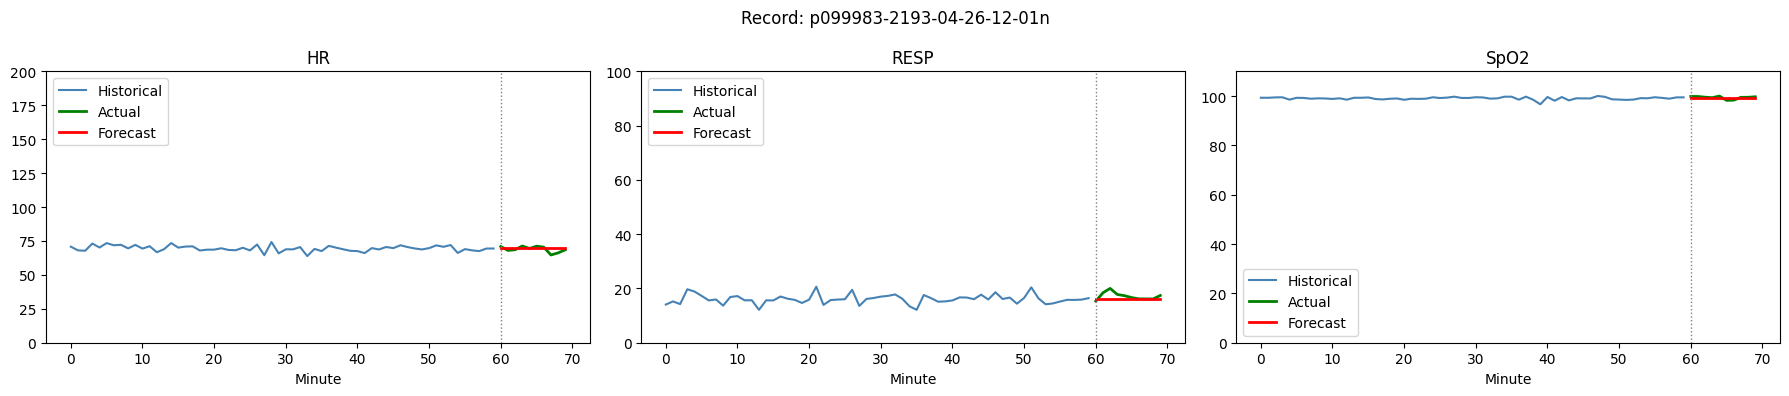

=== Alert Hit Rate by Vital ===
       Hits  Total HitRate
Vital                     
HR     1895   1998   94.8%
RESP   1129   1992   56.7%
SpO2   1680   1996   84.2%

=== Per-Vital Classification Report ===

--- HR ---
              precision    recall  f1-score   support

      stable       0.96      0.99      0.98      1710
     warning       0.86      0.69      0.77       236
   emergency       0.89      0.65      0.76        52

    accuracy                           0.95      1998
   macro avg       0.91      0.78      0.83      1998
weighted avg       0.95      0.95      0.95      1998


--- RESP ---
              precision    recall  f1-score   support

      stable       0.42      0.95      0.58       466
     warning       0.63      0.44      0.51       864
   emergency       0.94      0.47      0.62       662

    accuracy                           0.57      1992
   macro avg       0.66      0.62      0.57      1992
weighted avg       0.68      0.57      0.57      1992


---

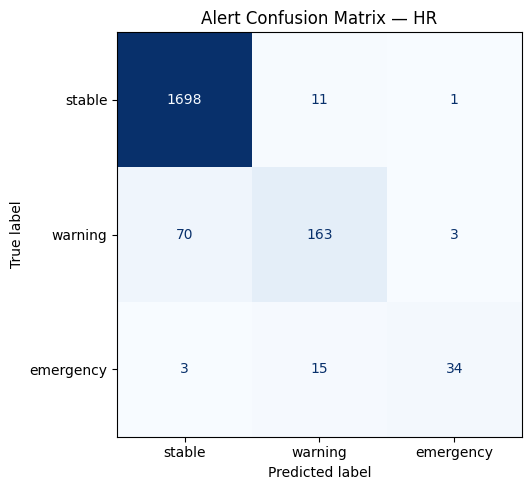

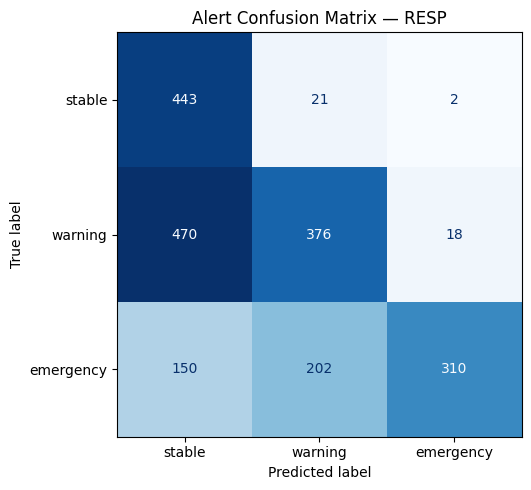

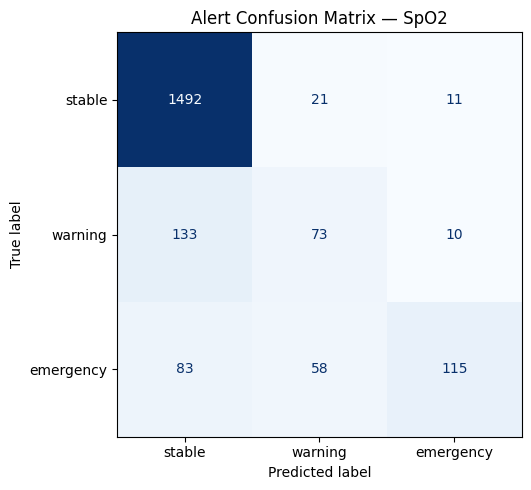


MAE by vital:


,count,mean,std,min,25%,50%,75%,max
Vital,,,,,,,,
HR,1998.0,2.535010,3.079402,0.0,0.950186,1.737064,3.106415,68.439677
RESP,1992.0,1.995221,1.704668,0.0,0.959168,1.654311,2.502675,21.536094
SpO2,1996.0,1.010903,2.072130,0.0,0.193115,0.495521,1.013368,28.079708


In [16]:
warnings.filterwarnings('ignore')

TARGET_VITALS = ['HR', 'RESP', 'SpO2']
VITAL_YLIM = {
    'HR':   (0, 200),
    'RESP': (0, 100),
    'SpO2': (0, 110)
}

### delay=25 discards first 25 minutes of the record, so 30 minutes total ###
def fit_and_evaluate_arima(df, train_len=60, pred_len=10, delay=25, verbose=False):
    results = []
    alerts = []
    record_count = 0

    for record, grp in df.groupby("Record"):
        grp = grp.sort_values("Minute").reset_index(drop=True)
        vital_plots = {}
        all_vitals_ok = True
        record_count += 1

        for vital in TARGET_VITALS:
            ### replacing 0 with nan to impute ###
            series = grp[vital].replace(0, np.nan).ffill().bfill().dropna()

            train_series = series.iloc[:train_len]
            test_series  = series.iloc[train_len:train_len + pred_len]

            if len(test_series) < pred_len:
                all_vitals_ok = False
                continue

            try:
                fitted = auto_arima(
                    train_series,
                    seasonal=False,
                    stepwise=True,
                    suppress_warnings=True,
                    with_intercept=True,
                    error_action='ignore'
                )

                forecast = fitted.predict(n_periods=pred_len)
                actuals  = test_series.values

                mae = np.abs(forecast - test_series.values).mean()
                mask = actuals != 0
                mape = (np.abs((forecast[mask] - actuals[mask]) / actuals[mask])).mean() * 100
                rmse = np.sqrt(((forecast - actuals) ** 2).mean())

                results.append({
                    "Record": record,
                    "Vital":  vital,
                    "Order":  fitted.order,
                    "MAE":    mae,
                    "MAPE":   mape,
                    "RMSE":   rmse
                })

                alert_result = evaluate_alert_hitrate(forecast, actuals, vital)
                alert_result["Record"] = record
                alerts.append(alert_result)

                vital_plots[vital] = (train_series, actuals, forecast)

                if verbose or record_count % 40 == 0:
                    print(f"  {record} | {vital} | order={fitted.order} | MAE={mae:.3f} | MAPE={mape:.3f} | RMSE={rmse:.3f}")
            except Exception as e:
                all_vitals_ok = False
                print(f"  {record} | {vital} | Failed: {e}")

        if all_vitals_ok and record_count % 40 == 0:
            fig, axes = plt.subplots(1, 3, figsize=(18, 4))
            fig.suptitle(f"Record: {record}", fontsize=12)

            for ax, vital in zip(axes, TARGET_VITALS):
                train_series, actuals, forecast = vital_plots[vital]
                train_x    = np.arange(len(train_series))
                forecast_x = np.arange(len(train_series), len(train_series) + pred_len)

                ax.plot(train_x,    train_series.values, color='steelblue', label='Historical')
                ax.plot(forecast_x, actuals,             color='green',     label='Actual',   linewidth=2)
                ax.plot(forecast_x, forecast,            color='red',       label='Forecast', linewidth=2)
                ax.axvline(x=len(train_series), color='gray', linestyle=':', linewidth=1)
                ax.set_title(vital)
                ax.set_xlabel("Minute")
                ax.set_ylim(VITAL_YLIM[vital])
                ax.legend()

            plt.tight_layout()
            plt.show()

    return pd.DataFrame(results), summarize_alert_hitrate(alerts)

results_df, alerts_df = fit_and_evaluate_arima(sampled_df, train_len=60, pred_len=10, delay=25, verbose=False)

print("\nMAE by vital:")
results_df.groupby("Vital")["MAE"].describe()

In [17]:
results_df.groupby("Vital")["MAE"].describe()[['mean', 'std', '50%']]

,mean,std,50%
Vital,,,
HR,2.535010,3.079402,1.737064
RESP,1.995221,1.704668,1.654311
SpO2,1.010903,2.072130,0.495521


In [18]:
results_df.to_csv("arima_results.csv", index=False)

In [19]:
alerts_df.to_csv("arima_results_alerts.csv", index=False)